# Megabanks vs Regional Banks — Analysis

Picks up from `data/processed/processed_dataframes/DataframeLong.parquet`: cleans and reshapes the pipeline output, independently recalculates ROA/ROE as a cross-check against FDIC Call Report figures, assembles a wide `master` dataframe (one row per bank-year, cohort-labeled) saved to `data/master_dataframe.csv`, and charts ROE, ROA, NIM, Efficiency Ratio, and AOCI-normalized trends by cohort.

See the project README for the cohort definitions (megabanks / resilient regional / failed regionals) and the pipeline stages that produce the input parquet file.


**Scope note: small, unbalanced sample**

This analysis covers 6 banks / ~21 bank-years (2 megabanks x 4 years, 1 resilient
regional x 4 years, 3 failed regionals x 3 years each, they stopped filing after
FY2022). Cohorts are unbalanced by construction (2 / 1 / 3 banks) and bank-years
within a cohort aren't independent draws -- multiple years from the same bank are
autocorrelated, most visibly for "resilient regional," which is a single bank (PNC).
Treat findings throughout as directional, descriptive evidence from a small,
non-random sample and not real statistical proof.

In [1]:
import json

import pandas as pd
import pyarrow
from pathlib import Path
from datetime import datetime
import yfinance as yf
import requests


In [2]:
df = pd.read_parquet("data/processed/processed_dataframes/DataframeLong.parquet")

In [3]:
df

,cik,company_name,source_file,year,quarter,metric,value_usd,concept,end_date,filed,accession_number
0,0000070858,BANK OF AMERICA CORP,BAC.json,2020,FY,total_assets,2819627000000,us-gaap:Assets,2020-12-31,2021-02-24,0000070858-21-000023
1,0000070858,BANK OF AMERICA CORP,BAC.json,2020,FY,net_income,17894000000,us-gaap:NetIncomeLoss,2020-12-31,2021-02-24,0000070858-21-000023
2,0000070858,BANK OF AMERICA CORP,BAC.json,2020,FY,stockholders_equity,272924000000,us-gaap:StockholdersEquity,2020-12-31,2021-02-24,0000070858-21-000023
3,0000070858,BANK OF AMERICA CORP,BAC.json,2020,FY,noninterest_expense,55213000000,us-gaap:NoninterestExpense,2020-12-31,2021-02-24,0000070858-21-000023
4,0000070858,BANK OF AMERICA CORP,BAC.json,2020,FY,interest_income,51585000000,us-gaap:InterestAndDividendIncomeOperating,2020-12-31,2021-02-24,0000070858-21-000023
...,...,...,...,...,...,...,...,...,...,...,...
268,0000719739,SVB Financial Group,SIVB.json,2022,FY,net_interest_income,4485000000,us-gaap:InterestIncomeExpenseNet,2022-12-31,2023-02-24,0000719739-23-000021
269,0000719739,SVB Financial Group,SIVB.json,2022,FY,interest_expense_deposits,862000000,us-gaap:InterestExpenseDeposits,2022-12-31,2023-02-24,0000719739-23-000021
270,0000719739,SVB Financial Group,SIVB.json,2022,FY,held_to_maturity_securities,91327000000,us-gaap:HeldToMaturitySecurities,2022-12-31,2023-02-24,0000719739-23-000021
271,0000719739,SVB Financial Group,SIVB.json,2022,FY,held_to_maturity_securities_fair_value,76169000000,us-gaap:HeldToMaturitySecuritiesFairValue,2022-12-31,2023-02-24,0000719739-23-000021


In [4]:
#Decided to fill missing values in the assymetyric data coverage of PDF-derived banks (SBNY, FRB)
#Also accounted for derived calculations like interest_income_plus_noninterest_income
df["filed"] = df["filed"].fillna("not provided")
df["end_date"] = df["end_date"].fillna("not provided")
df["concept"] = df["concept"].fillna("derived calculation")
df["accession_number"] = df["accession_number"].fillna("not provided")
df["cik"] = df["cik"].fillna("0000000000")


#Added a ticker column for JOIN between the dataframes
bank_tickers = {
    "BANK OF AMERICA CORP": "BAC",
    "First Republic Bank": "FRCB",
    "JPMORGAN CHASE & CO": "JPM",
    "PNC FINANCIAL SERVICES GROUP, INC.": "PNC",
    "Signature Bank": "SBNY",
    "SVB Financial Group": "SIVB",
}

df["ticker"] = df["company_name"].map(bank_tickers)

In [5]:
# INDEPENDENT ROA/ROE CALCULATIONS (cross-check against FDIC Call Report figures)

"""ROA CALCULATIONS (net income / average total assets) for 10-K data"""
total_assets = df.loc[df["metric"] == "total_assets"]
avg_assets = (
    total_assets.groupby(["ticker", "year"], as_index=False)["value_usd"]
    .sum()
    .assign(
        avg_total_assets=lambda df: (
                                            df["value_usd"] +
                                            df.groupby("ticker")["value_usd"].shift()
                                    ) / 2
    )
    [["ticker", "year", "avg_total_assets"]]
)

avg_assets["avg_total_assets"] = avg_assets["avg_total_assets"].astype("Int64")
net_income = df.loc[df["metric"] == "net_income"]
net_income = net_income[["ticker", "year", "value_usd"]]
net_income = net_income.reset_index()
avg_assets = avg_assets.reset_index()
series = pd.merge(net_income, avg_assets, on=["ticker", "year"])
series = series.drop("index_y", axis=1)
series = series.rename(columns={"value_usd": "net_income"})
series["ROA"] = series["net_income"] / series["avg_total_assets"]
series = series.set_index("index_x")
ROA = series
#CALCULATED ROA per bank, per year

"""ROE CALCULATIONS"""
total_equity = df.loc[df["metric"] == "stockholders_equity"]
avg_equity = (
    total_equity.groupby(["ticker", "year"], as_index=False)["value_usd"]
    .sum()
    .assign(
        average_total_equity=lambda df: ((
             df["value_usd"] +
             df.groupby("ticker")["value_usd"]
             .shift()) / 2)
    )
)

avg_equity["average_total_equity"] = avg_equity["average_total_equity"].astype("Int64")
net_income = net_income.rename(columns={"value_usd": "net_income"})
avg_equity = avg_equity.reset_index()
avg_equity["ROE"] = net_income["net_income"] / avg_equity["average_total_equity"]
#CALCULATED ROE per yer, per company
ROE = avg_equity
ROE["ROE"] = ROE["ROE"] * 10
ROE = ROE.drop(columns="index")

In [6]:
"""Reading call reports for: ROA, ROE, NIM, Efficiency ratio, Uninsured Deposit %"""
FDIC_DIR = "data/raw/FDIC_Call_Reports"

def import_call_reports(fdic_dir=FDIC_DIR):
    #Read all the json files in the specified FDIC_Call_Reports directory
    for filepath in Path(fdic_dir).glob("*.json"):
        with open(filepath, "r") as f:
            data = json.load(f)
            yield data

dataset = import_call_reports()
call_report_dict = {}

#Mapping to assign real bank names to the data instead of the ambigous CERT numbers
fdic_dict = {
    "3510": "BAC",
    "59017": "FRCB",
    "628": "JPM",
    "6384": "PNC",
    "57053": "SBNY",
    "24735": "SIVB",
}

#Assigns
for data in dataset:
    call_report_dict.update({f"{fdic_dict[data["meta"]["parameters"]["filters"].split(":")[1]]}": data})

def parse_metrics(fdic_num_map, call_reports):
    records = []
    for bank_name in fdic_num_map.values():
        for n in range(len(call_reports[bank_name]["data"])):
            date_of_report = call_reports[bank_name]["data"][n]["data"]["ID"].split("_")[1]    # Prints all call report dates
            if 20200000 < int(date_of_report) < 20240000:          # Prints only those that exist between 2020 - 2024
                per_year_metrics = call_reports[bank_name]["data"][n]["data"]
                records.append({
                    "Name": bank_name,
                    "Date": date_of_report,
                    "NIM": per_year_metrics["NIMY"],
                    "ROA": per_year_metrics["ROA"],
                    "ROE": per_year_metrics["ROE"],
                    "ER": per_year_metrics["EEFFR"],
                    # DEPUNA = uninsured domestic deposits, DEP = total deposits.
                    "uninsured_deposit_percent": per_year_metrics["DEPUNA"] / per_year_metrics["DEP"] * 100
                    })
    return records


all_records = []
all_records.extend(parse_metrics(fdic_dict, call_report_dict))
calculated_metrics = pd.DataFrame(all_records)
calculated_metrics["Date"] = pd.to_datetime(calculated_metrics["Date"])     # Raw quarterly data
quarterly_metrics = calculated_metrics
calculated_metrics["Year"] = calculated_metrics["Date"].dt.year      # Annualized data

In [7]:
# Creates a MultiIndex dataframe, grouped by annual mean metrics, no longer quarterly
calculated_metrics = calculated_metrics.groupby(["Name", "Year"])[['NIM', 'ROA', 'ROE', 'ER', 'uninsured_deposit_percent']].agg("mean")

In [8]:
# Flatten from mulitindex into regular Dataframe
calculated_metrics = calculated_metrics.reset_index()

In [9]:
calculated_metrics = calculated_metrics.rename(columns={"Name": "ticker", "Year": "year"})

"""VALIDATING ROE"""
validate_ROE = pd.merge(calculated_metrics, ROE, how="left", on=["ticker", "year"])
validate_ROE = validate_ROE[["ticker", "year", "ROE_x", "ROE_y"]]
validate_ROE["ROE_y"] = validate_ROE["ROE_y"] * 10
validate_ROE = validate_ROE.rename(columns={"ROE_x": "ROE_CR", "ROE_y": "ROE_10K"})
validate_ROE["percentage_diff"] = round(validate_ROE["ROE_CR"] / validate_ROE["ROE_10K"] * 100, 2)

In [10]:
# Manually checking for discrepancies between ROE derived from 10-K filings and Call Report data.
validate_ROE[validate_ROE["percentage_diff"] > 115]

,ticker,year,ROE_CR,ROE_10K,percentage_diff
3,BAC,2023,13.7875,9.38845,146.86
13,PNC,2021,12.4600,10.437081,119.38
15,PNC,2023,13.9225,11.657841,119.43
21,SIVB,2022,13.8475,9.98139,138.73


In [11]:
validate_ROE[validate_ROE["percentage_diff"] < 75]

,ticker,year,ROE_CR,ROE_10K,percentage_diff


In [12]:
"""VALIDATING ROA"""
validate_ROA = pd.merge(calculated_metrics, ROA, how="left", on=["ticker", "year"])
validate_ROA = validate_ROA[["ticker", "year", "ROA_x", "ROA_y"]]
validate_ROA["ROA_y"] = validate_ROA["ROA_y"] * 100
validate_ROA = validate_ROA.rename(columns={"ROA_x": "ROA_CR", "ROA_y": "ROA_10K"})
validate_ROA["percentage_diff"] = round(validate_ROA["ROA_CR"] / validate_ROA["ROA_10K"] * 100, 2)

In [13]:
# Manually checking for discrepancies between ROA derived from 10-K filings and Call Report data.
validate_ROA[validate_ROA["percentage_diff"] > 115]

,ticker,year,ROA_CR,ROA_10K,percentage_diff
3,BAC,2023,1.282152,0.850995,150.67
21,SIVB,2022,0.972140,0.760269,127.87


In [14]:
validate_ROA[validate_ROA["percentage_diff"] < 75]

,ticker,year,ROA_CR,ROA_10K,percentage_diff
20,SIVB,2021,0.823922,1.267933,64.98


In [15]:
"""CALCULATING & VALIDATING THE EFFICIENCY RATIO"""
# Calculating in order the check the validity of Call Report data
non_interest_expense = df[df["metric"] == 'noninterest_expense'][["ticker", "year", "value_usd"]]
net_interest_income = df[df["metric"] == 'net_interest_income'][["ticker", "year", "value_usd"]]
non_interest_income = df[df["metric"] == 'noninterest_income'][["ticker", "year", "value_usd"]]

non_interest_expense = non_interest_expense.reset_index()
net_interest_income = net_interest_income.reset_index()
non_interest_income = non_interest_income.reset_index()

combined_1 = pd.merge(non_interest_expense, net_interest_income, how="left", on=["ticker", "year"]).rename(
    columns={"value_usd_x": "non_interest_expense", "value_usd_y": "net_interest_income"}).drop(columns=["index_y"])

combined_2 = pd.merge(combined_1, non_interest_income, how="left", on=["ticker", "year"]).drop(
    columns=["index", "index_x"]).rename(columns={"value_usd": "non_interest_income"})

combined_2["efficiency_ratio"] = combined_2["non_interest_expense"] / (
            combined_2["net_interest_income"] + combined_2["non_interest_income"])

combined_2["efficiency_ratio"] = combined_2["efficiency_ratio"] * 100

efficiency_ratio = combined_2
efficiency_ratio = efficiency_ratio[["ticker", "year", "efficiency_ratio"]]

validate_ER = pd.merge(calculated_metrics, efficiency_ratio, how="left", on=["ticker", "year"])[
    ["ticker", "year", "ER", "efficiency_ratio"]]
validate_ER = validate_ER.rename(columns={"efficiency_ratio": "10-K ER", "ER": "CR ER"})
validate_ER["percentage_diff"] = validate_ER["10-K ER"] / validate_ER["CR ER"] * 100

validate_ER.to_csv("ER.csv")
validate_ROA.to_csv("ROA.csv")
validate_ROE.to_csv("ROE.csv")

In [16]:
validate_ER.loc[validate_ER["percentage_diff"] > 115]

,ticker,year,CR ER,10-K ER,percentage_diff
0,BAC,2020,55.551594,64.555467,116.208128
3,BAC,2023,53.733864,66.792790,124.302973
21,SIVB,2022,46.965863,58.281024,124.092309


In [17]:
validate_ER.loc[validate_ER["percentage_diff"] < 75]

,ticker,year,CR ER,10-K ER,percentage_diff


**OBSERVATION**

Silion Valley Bank (SIVB) and Bank of America (BAC) have strong discrepancies across both ROE, ROA and ER between data derived from 10-Ks vs FDIC Call
Reports, especially for 2022 and 2023. This is confirmed as not a data quality issue, but the results of how 10-K filings and FDIC Call Reports, often contain data not available in the other type of record. With SIVB, an over 700M+ dollar swing into pre-tax losses that is present in the 10-K, doesn't show up in the Call Report. BAC on the other hand, took a $2.8B hit to it's income statements in 2023, which due to the differences in accounting practices, only showed up in the Call Report for the year, and not the 10-K.

In [18]:
wide_df = df.loc[df["metric"] == 'noninterest_income'].head(0)
for metric in df["metric"].values.unique():
    part_df = df.loc[df["metric"] == metric]
    wide_df = pd.concat([wide_df, part_df], axis=0, join="outer", ignore_index=True)

In [19]:
#2020 data retained (previously dropped here)

In [20]:
wide_df

,cik,company_name,source_file,year,quarter,metric,value_usd,concept,end_date,filed,accession_number,ticker
0,0000070858,BANK OF AMERICA CORP,BAC.json,2020,FY,total_assets,2819627000000,us-gaap:Assets,2020-12-31,2021-02-24,0000070858-21-000023,BAC
1,0000070858,BANK OF AMERICA CORP,BAC.json,2021,FY,total_assets,3169495000000,us-gaap:Assets,2021-12-31,2022-02-22,0000070858-22-000062,BAC
2,0000070858,BANK OF AMERICA CORP,BAC.json,2022,FY,total_assets,3051375000000,us-gaap:Assets,2022-12-31,2023-02-22,0000070858-23-000092,BAC
3,0000070858,BANK OF AMERICA CORP,BAC.json,2023,FY,total_assets,3180151000000,us-gaap:Assets,2023-12-31,2024-02-20,0000070858-24-000122,BAC
4,0000000000,First Republic Bank,['parsed_financials_First_Republic_Bank_10-K_2...,2020,FY,total_assets,142502000000,pdf-derived:total_assets,"December 31, 2020",not provided,not provided,FRCB
...,...,...,...,...,...,...,...,...,...,...,...,...
268,0000000000,Signature Bank,['parsed_financials_Signature_Bank_10-K_2021.j...,2021,FY,interest_income_plus_noninterest_income,2311273000,derived calculation,not provided,not provided,not provided,SBNY
269,0000000000,Signature Bank,['parsed_financials_Signature_Bank_10-K_2021.j...,2022,FY,interest_income_plus_noninterest_income,3711374000,derived calculation,not provided,not provided,not provided,SBNY
270,0000719739,SVB Financial Group,SIVB.json,2020,FY,interest_income_plus_noninterest_income,4081758000,derived calculation,not provided,not provided,not provided,SIVB
271,0000719739,SVB Financial Group,SIVB.json,2021,FY,interest_income_plus_noninterest_income,6027000000,derived calculation,not provided,not provided,not provided,SIVB


In [21]:
wide = (
    wide_df.pivot_table(
        index=["company_name", "ticker", "year"],
        columns="metric",
        values="value_usd",
        aggfunc="first"      # or "sum", "mean", etc.
    )
    .reset_index()
)

In [22]:
wide[['accumulated_other_comprehensive_income_loss', 'interest_income',
       'interest_income_plus_noninterest_income', 'net_income',
       'net_interest_income', 'noninterest_expense', 'noninterest_income',
       'stockholders_equity', 'total_assets', 'total_deposits_consolidated',
       'held_to_maturity_securities', 'held_to_maturity_securities_fair_value']] \
    = wide[['accumulated_other_comprehensive_income_loss', 'interest_income',
       'interest_income_plus_noninterest_income', 'net_income',
       'net_interest_income', 'noninterest_expense', 'noninterest_income',
       'stockholders_equity', 'total_assets', 'total_deposits_consolidated',
       'held_to_maturity_securities', 'held_to_maturity_securities_fair_value']].astype("Int64")

In [23]:
"""MASTER DATAFRAME ASSEMBLY"""
# This dataframe will be the subject of analysis. It has been made into a wide format to accomodate the creation of data   visualization and easy quering.
wide

metric,company_name,ticker,year,accumulated_other_comprehensive_income_loss,held_to_maturity_securities,held_to_maturity_securities_fair_value,interest_expense_deposits,interest_income,interest_income_plus_noninterest_income,net_income,net_interest_income,noninterest_expense,noninterest_income,stockholders_equity,total_assets,total_deposits_consolidated
0,BANK OF AMERICA CORP,BAC,2020,-1656000000,438279000000,448180000000,1943000000,51585000000,93753000000,17894000000,43360000000,55213000000,42168000000,272924000000,2819627000000,1795480000000
1,BANK OF AMERICA CORP,BAC,2021,-5104000000,674591000000,665890000000,537000000,47672000000,93851000000,31978000000,42934000000,59731000000,46179000000,270066000000,3169495000000,2064446000000
2,BANK OF AMERICA CORP,BAC,2022,-21156000000,632825000000,524267000000,4718000000,72565000000,115053000000,27528000000,52462000000,61438000000,42488000000,273197000000,3051375000000,1930341000000
3,BANK OF AMERICA CORP,BAC,2023,-17788000000,594555000000,496597000000,26163000000,130262000000,171912000000,26515000000,56931000000,65845000000,41650000000,291646000000,3180151000000,1923827000000
4,First Republic Bank,FRCB,2020,23000000,16603000000,17964000000,276000000,3853000000,4508000000,1064000000,3262000000,2426000000,655000000,11751000000,142502000000,114929000000
5,First Republic Bank,FRCB,2021,-31000000,22292000000,23422000000,95000000,4385000000,5305000000,1478000000,4114000000,3147000000,920000000,15898000000,181087000000,156321000000
6,First Republic Bank,FRCB,2022,-331000000,28348000000,23587000000,654000000,5722000000,6753000000,1665000000,4834000000,3617000000,1031000000,17446000000,212639000000,176437000000
7,JPMORGAN CHASE & CO,JPM,2020,7986000000,201899000000,205472000000,2357000000,64523000000,129503000000,29131000000,54563000000,66656000000,64980000000,279354000000,3386071000000,2144257000000
8,JPMORGAN CHASE & CO,JPM,2021,-84000000,363707000000,362628000000,531000000,57864000000,127202000000,48334000000,52311000000,71343000000,69338000000,294127000000,3743567000000,2462303000000
9,JPMORGAN CHASE & CO,JPM,2022,-17341000000,425305000000,388648000000,10082000000,92807000000,154792000000,37676000000,66710000000,76140000000,61985000000,292332000000,3665743000000,2340179000000


In [24]:
# The final JOIN between 10-K derived data (wide) and Call Report metrics (calculated_metrics)
master = pd.merge(wide, calculated_metrics, how="left", on=["ticker", "year"])

In [25]:
# Adding a cohort classification, which from this point onwards will serve an important role in grouping financial data
cohort_map = {
    "BAC": "megabank",
    "JPM": "megabank",
    "PNC": "resilient regional",
    "SIVB": "failed regional",
    "FRCB": "failed regional",
    "SBNY": "failed regional"
}

master["cohort"] = master["ticker"].map(cohort_map)

In [26]:
master.to_csv("data/master_dataframe.csv")

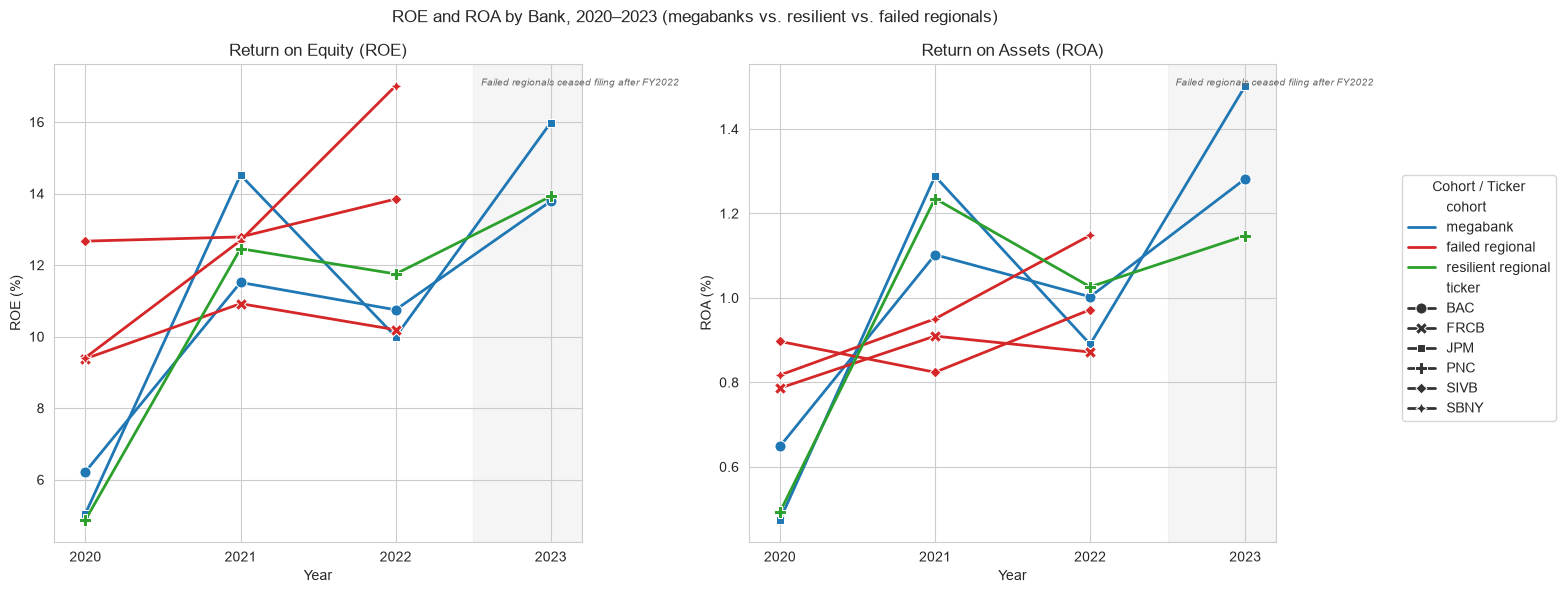

In [27]:
"""ROE & ROA TRENDS (2020-2023), by bank, colored by cohort"""
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

cohort_palette = {
    "megabank": "#1f77b4",
    "resilient regional": "#2ca02c",
    "failed regional": "#d62728",
}

def flag_unbalanced_panel(ax, cutoff=2022.5, label="Failed regionals ceased filing after FY2022"):
    ax.axvspan(cutoff, ax.get_xlim()[1], color="grey", alpha=0.08, zorder=0)
    ax.text(cutoff + 0.05, 0.97, label, transform=ax.get_xaxis_transform(),
            fontsize=7, style="italic", color="dimgrey", va="top")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

for ax, metric_col, title in zip(axes, ["ROE", "ROA"], ["Return on Equity (ROE)", "Return on Assets (ROA)"]):
    sns.lineplot(
        data=master,
        x="year",
        y=metric_col,
        hue="cohort",
        style="ticker",
        palette=cohort_palette,
        markers=True,
        dashes=False,
        markersize=8,
        linewidth=2,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(f"{metric_col} (%)")
    ax.set_xticks([2020, 2021, 2022, 2023])
    ax.set_xlim(2019.8, 2023.2)
    flag_unbalanced_panel(ax)

# Single shared legend (bank + cohort), de-duplicated across the two axes
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend_.remove()
axes[1].legend_.remove()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), title="Cohort / Ticker")

fig.suptitle("ROE and ROA by Bank, 2020–2023 (megabanks vs. resilient vs. failed regionals)")
plt.tight_layout()
plt.show()

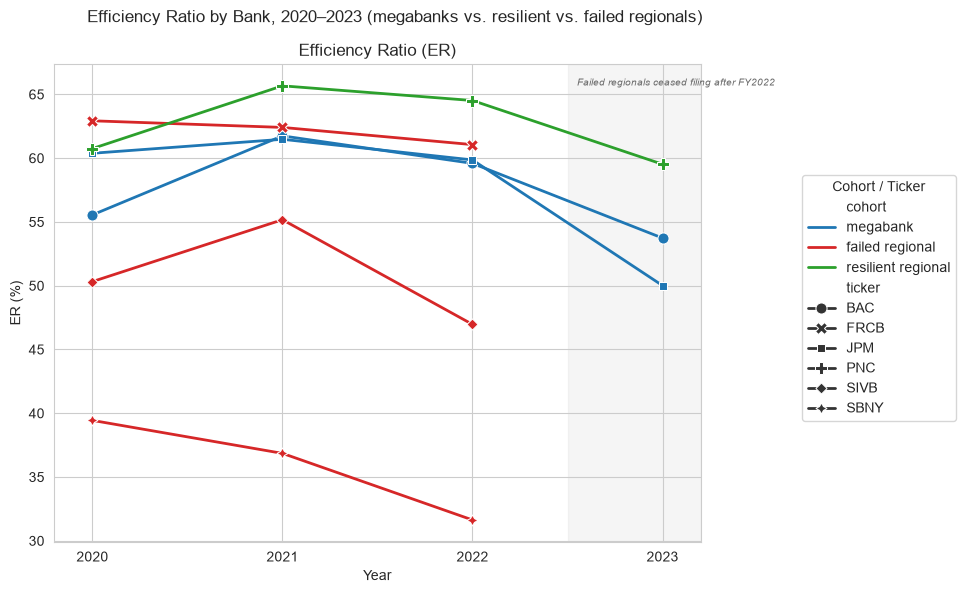

In [28]:
"""EFFICIENCY RATIO TRENDS (2020-2023), by bank, colored by cohort"""
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sns.lineplot(
    data=master,
    x="year",
    y="ER",
    hue="cohort",
    style="ticker",
    palette=cohort_palette,
    markers=True,
    dashes=False,
    markersize=8,
    linewidth=2,
    ax=ax,
)
ax.set_title("Efficiency Ratio (ER)")
ax.set_xlabel("Year")
ax.set_ylabel("ER (%)")
ax.set_xticks([2020, 2021, 2022, 2023])
ax.set_xlim(2019.8, 2023.2)
flag_unbalanced_panel(ax)

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), title="Cohort / Ticker")

fig.suptitle("Efficiency Ratio by Bank, 2020–2023 (megabanks vs. resilient vs. failed regionals)")
plt.tight_layout()
plt.show()

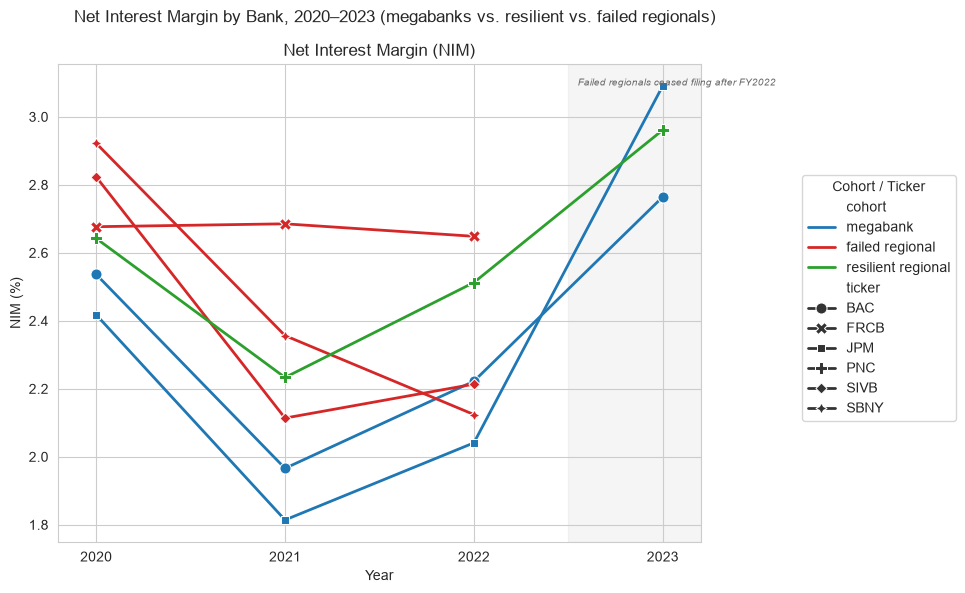

'OBSERVATION'

In [29]:
"""NET INTEREST MARGIN TRENDS (2020-2023), by bank, colored by cohort"""
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sns.lineplot(
    data=master,
    x="year",
    y="NIM",
    hue="cohort",
    style="ticker",
    palette=cohort_palette,
    markers=True,
    dashes=False,
    markersize=8,
    linewidth=2,
    ax=ax,
)
ax.set_title("Net Interest Margin (NIM)")
ax.set_xlabel("Year")
ax.set_ylabel("NIM (%)")
ax.set_xticks([2020, 2021, 2022, 2023])
ax.set_xlim(2019.8, 2023.2)
flag_unbalanced_panel(ax)

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), title="Cohort / Ticker")

fig.suptitle("Net Interest Margin by Bank, 2020–2023 (megabanks vs. resilient vs. failed regionals)")
plt.tight_layout()
plt.show()

"""OBSERVATION"""
# The failed regionals are showing a strong degree of NIM compression. This is unusual, on the account that rising rates(something that happened in 2022 and 2023) usually benefit the interest margins of banks during their initial implementation.

In [30]:
"""2020-2022 TREND SLOPES: ROE and Efficiency Ratio, per bank (simple linear fit)"""
from scipy.stats import linregress

trend_years = [2020, 2021, 2022]
trend_df = master.loc[master["year"].isin(trend_years)]

def compute_slope(group, col):
    group = group.dropna(subset=[col])
    if len(group) < 2:
        return pd.Series({f"{col}_slope": pd.NA, f"{col}_pvalue": pd.NA, f"{col}_rsq": pd.NA})
    fit = linregress(group["year"], group[col])
    return pd.Series({
        f"{col}_slope": fit.slope,
        f"{col}_pvalue": fit.pvalue,
        f"{col}_rsq": fit.rvalue ** 2,
    })

slopes = (
    trend_df.groupby(["ticker", "cohort"])
    .apply(lambda g: pd.concat([compute_slope(g, "ROE"), compute_slope(g, "ER")]))
    .reset_index()
)
slopes


,ticker,cohort,ROE_slope,ROE_pvalue,ROE_rsq,ER_slope,ER_pvalue,ER_rsq
0,BAC,megabank,2.26375,0.418717,0.626296,2.019474,0.556077,0.412370
1,FRCB,failed regional,0.40500,0.647579,0.276400,-0.933971,0.159815,0.938293
2,JPM,megabank,2.47250,0.650268,0.272630,-0.261329,0.795150,0.100017
3,PNC,resilient regional,3.43875,0.387146,0.673580,1.883582,0.477139,0.535879
4,SBNY,failed regional,3.79875,0.050810,0.993644,-3.903015,0.122503,0.963426
5,SIVB,failed regional,0.58875,0.275587,0.824022,-1.677772,0.733437,0.165314


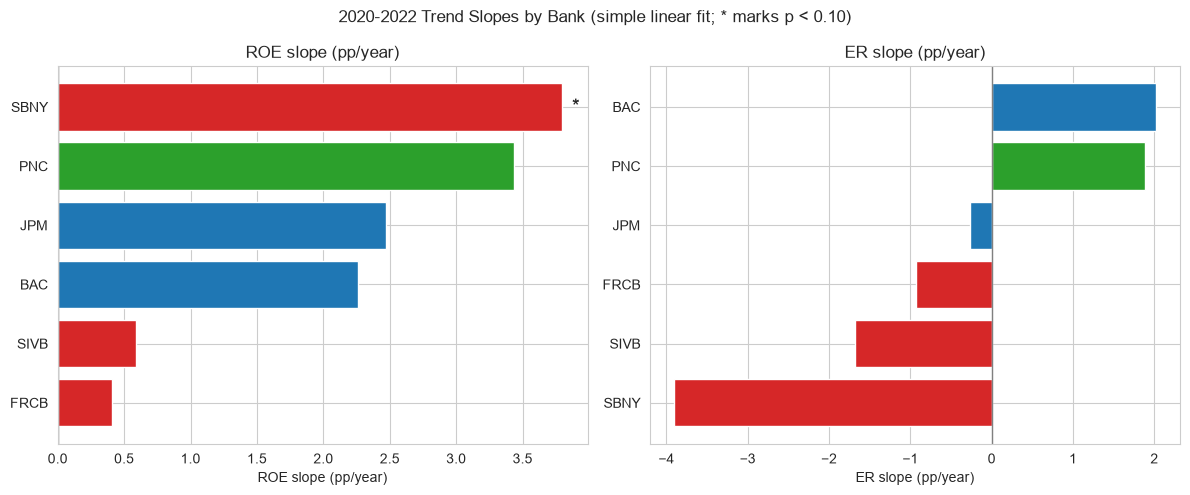

In [31]:
"""ROE & ER TREND-SLOPE SIGNIFICANCE (2020-2022), per bank, colored by cohort"""
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False)

for ax, col, title in zip(axes, ["ROE_slope", "ER_slope"], ["ROE slope (pp/year)", "ER slope (pp/year)"]):
    plot_df = slopes.dropna(subset=[col]).sort_values(col)
    bar_colors = plot_df["cohort"].map(cohort_palette)
    bars = ax.barh(plot_df["ticker"], plot_df[col], color=bar_colors)
    ax.axvline(0, color="grey", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(title)

    pvalue_col = col.replace("_slope", "_pvalue")
    for bar, pval in zip(bars, plot_df[pvalue_col]):
        if pd.notna(pval) and pval < 0.10:
            x = bar.get_width()
            offset = 0.02 * (abs(x) if x else 1)
            ax.text(x + (offset if x >= 0 else -offset), bar.get_y() + bar.get_height() / 2,
                    "*", ha="left" if x >= 0 else "right", va="center", fontsize=13, fontweight="bold")

fig.suptitle("2020-2022 Trend Slopes by Bank (simple linear fit; * marks p < 0.10)")
plt.tight_layout()
plt.show()


**Reading the trend-slope chart**

Each slope is fit on only 3 points (2020-2022), so
the p-values above are for descriptive orientation, not hypothesis-test-grade evidence. Treat the `*` markers as "worth a
second look," not statistical significance.

In [32]:
# New metric to better understand the fiscal pressure,
master["AOCI normalized"] = (master["accumulated_other_comprehensive_income_loss"] / master["stockholders_equity"]) * 100

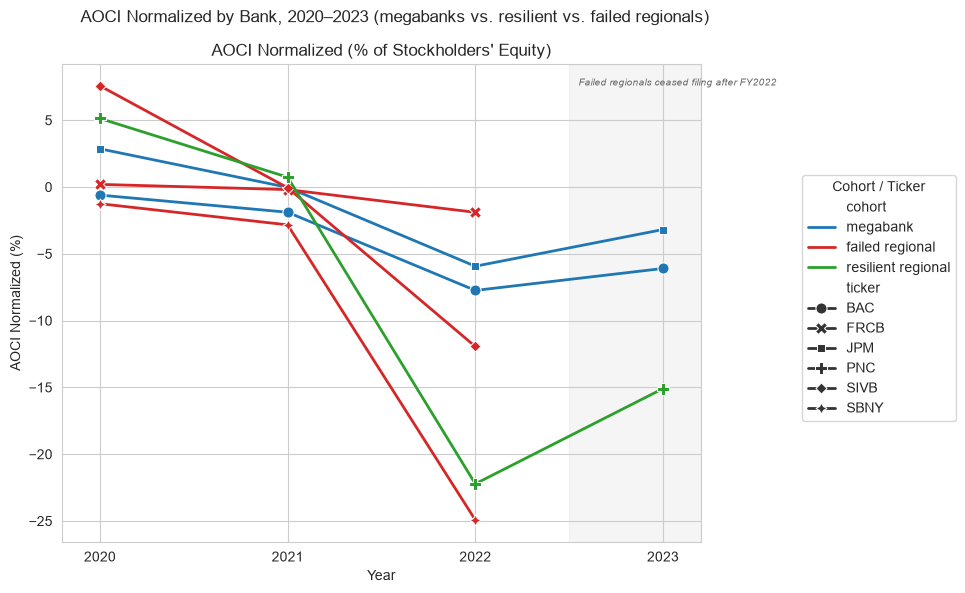

In [33]:
"""AOCI NORMALIZED TRENDS (2020-2023), by bank, colored by cohort"""
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sns.lineplot(
    data=master,
    x="year",
    y="AOCI normalized",
    hue="cohort",
    style="ticker",
    palette=cohort_palette,
    markers=True,
    dashes=False,
    markersize=8,
    linewidth=2,
    ax=ax,
)
ax.set_title("AOCI Normalized (% of Stockholders' Equity)")
ax.set_xlabel("Year")
ax.set_ylabel("AOCI Normalized (%)")
ax.set_xticks([2020, 2021, 2022, 2023])
ax.set_xlim(2019.8, 2023.2)
flag_unbalanced_panel(ax)

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), title="Cohort / Ticker")

fig.suptitle("AOCI Normalized by Bank, 2020–2023 (megabanks vs. resilient vs. failed regionals)")
plt.tight_layout()
plt.show()

In [34]:
master["HTM unrealized loss normalized"] = (
    (master["held_to_maturity_securities_fair_value"] - master["held_to_maturity_securities"])
    / master["stockholders_equity"]
) * 100

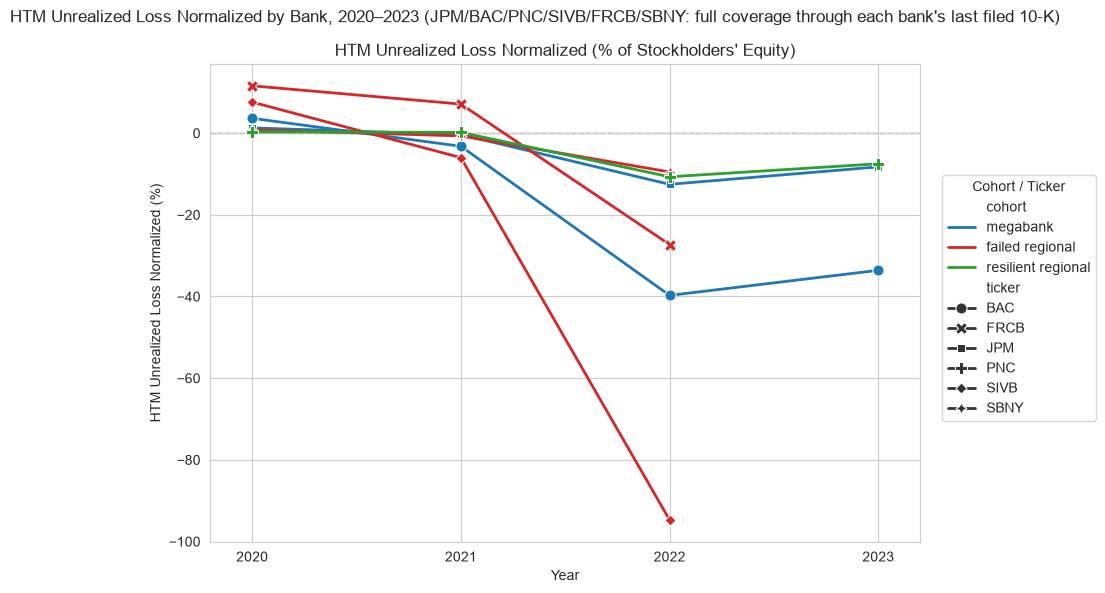

In [35]:
"""HTM UNREALIZED LOSS NORMALIZED TRENDS (2020-2023), by bank, colored by cohort"""
htm_chart_df = master.dropna(subset=["HTM unrealized loss normalized"])

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sns.lineplot(
    data=htm_chart_df,
    x="year",
    y="HTM unrealized loss normalized",
    hue="cohort",
    style="ticker",
    palette=cohort_palette,
    markers=True,
    dashes=False,
    markersize=8,
    linewidth=2,
    ax=ax,
)
ax.axhline(0, color="grey", linewidth=1, linestyle="--", zorder=0)
ax.set_title("HTM Unrealized Loss Normalized (% of Stockholders' Equity)")
ax.set_xlabel("Year")
ax.set_ylabel("HTM Unrealized Loss Normalized (%)")
ax.set_xticks([2020, 2021, 2022, 2023])
ax.set_xlim(2019.8, 2023.2)

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), title="Cohort / Ticker")

fig.suptitle("HTM Unrealized Loss Normalized by Bank, 2020–2023 (JPM/BAC/PNC/SIVB/FRCB/SBNY: full coverage through each bank's last filed 10-K)")
plt.tight_layout()
plt.show()

**HTM UNREALIZED LOSS NORMALIZED**

Before the rate hike, SIVB purchased a large amount of Securities at low discount rates, which meant that in the case of an eventual increase in rates, the market value of those Assets would plummet. This was made worse by SIVB hiding this loss by categorizing these Securities as HTM instead of AFS, as AFS goes straight into AOCI, while HTM remains out of the books. This meant that when SIVB was forced to sell these Securities to remedy the withdrawal pressures stemming from a large part of their deposits being uninsured, they had produced an overnight accounting nightmare, with the numbers showing >80% of their Stockholders' equity being swamped by Unrealized Losses, that were previously invisible in AOCI.

In [36]:
# Deposit growth/decline, YoY %, using the now-restored 2020 figures as the 2021 baseline
master = master.sort_values(["ticker", "year"]).reset_index(drop=True)
master["deposit_growth_pct"] = master.groupby("ticker")["total_deposits_consolidated"].pct_change() * 100

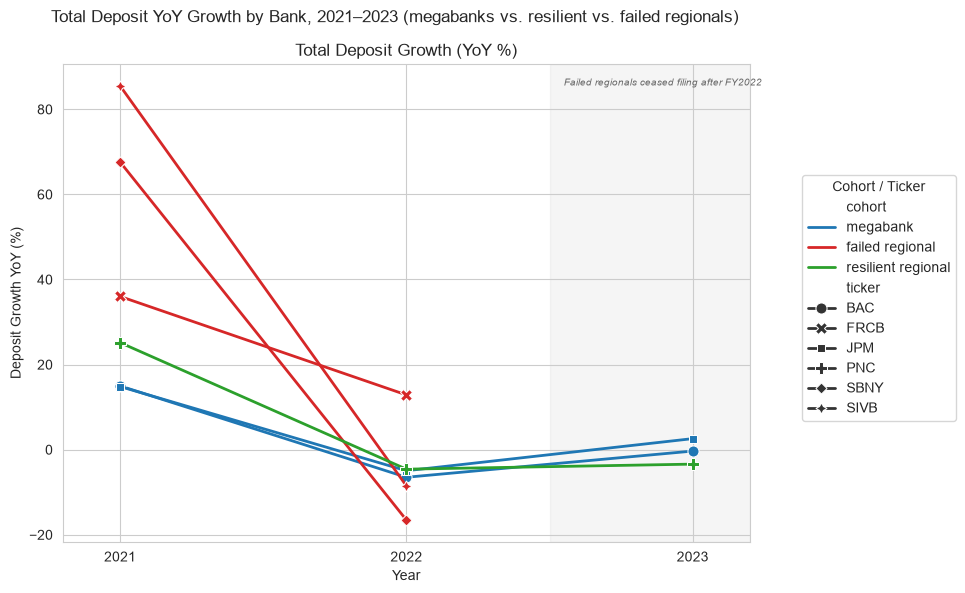

In [37]:
"""DEPOSIT GROWTH (YoY %) TRENDS (2021-2023), by bank, colored by cohort"""
deposit_growth_df = master.loc[master["year"] >= 2021]

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sns.lineplot(
    data=deposit_growth_df,
    x="year",
    y="deposit_growth_pct",
    hue="cohort",
    style="ticker",
    palette=cohort_palette,
    markers=True,
    dashes=False,
    markersize=8,
    linewidth=2,
    ax=ax,
)
ax.set_title("Total Deposit Growth (YoY %)")
ax.set_xlabel("Year")
ax.set_ylabel("Deposit Growth YoY (%)")
ax.set_xticks([2021, 2022, 2023])
ax.set_xlim(2020.8, 2023.2)
flag_unbalanced_panel(ax)

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), title="Cohort / Ticker")

fig.suptitle("Total Deposit YoY Growth by Bank, 2021–2023 (megabanks vs. resilient vs. failed regionals)")
plt.tight_layout()
plt.show()

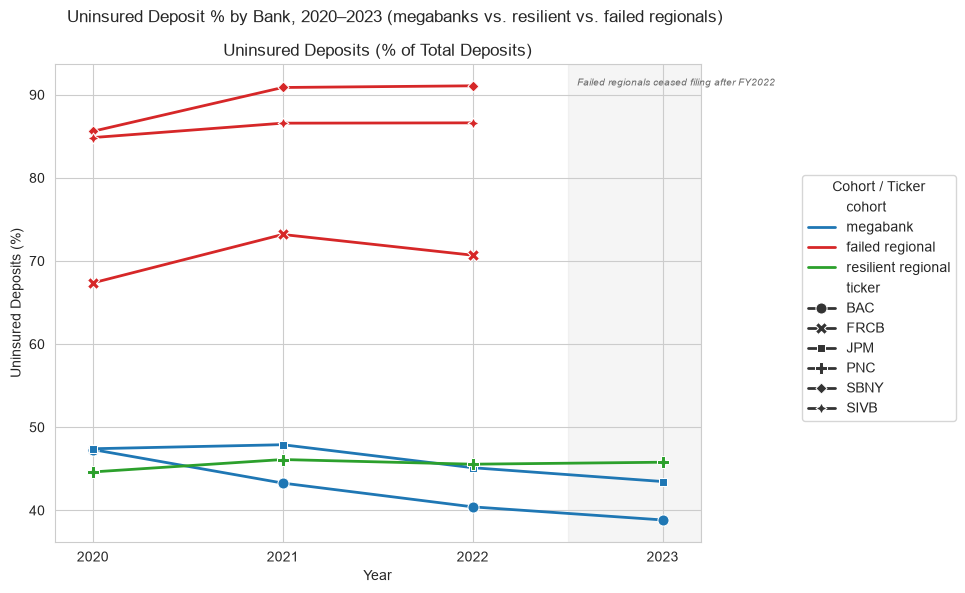

'OBSERVATION'

In [38]:
"""UNINSURED DEPOSIT % TRENDS (2020-2023), by bank, colored by cohort"""
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sns.lineplot(
    data=master,
    x="year",
    y="uninsured_deposit_percent",
    hue="cohort",
    style="ticker",
    palette=cohort_palette,
    markers=True,
    dashes=False,
    markersize=8,
    linewidth=2,
    ax=ax,
)
ax.set_title("Uninsured Deposits (% of Total Deposits)")
ax.set_xlabel("Year")
ax.set_ylabel("Uninsured Deposits (%)")
ax.set_xticks([2020, 2021, 2022, 2023])
ax.set_xlim(2019.8, 2023.2)
flag_unbalanced_panel(ax)

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), title="Cohort / Ticker")

fig.suptitle("Uninsured Deposit % by Bank, 2020–2023 (megabanks vs. resilient vs. failed regionals)")
plt.tight_layout()
plt.show()

"""OBSERVATION"""
# Strong evidence for how vulnerable the regional banks were. With the rate hike, we saw a flight into governemnt issued
# bonds and securites, this meant increased withdrawal pressures on regional banks with overextended capital and the
# subsequent bank runs.

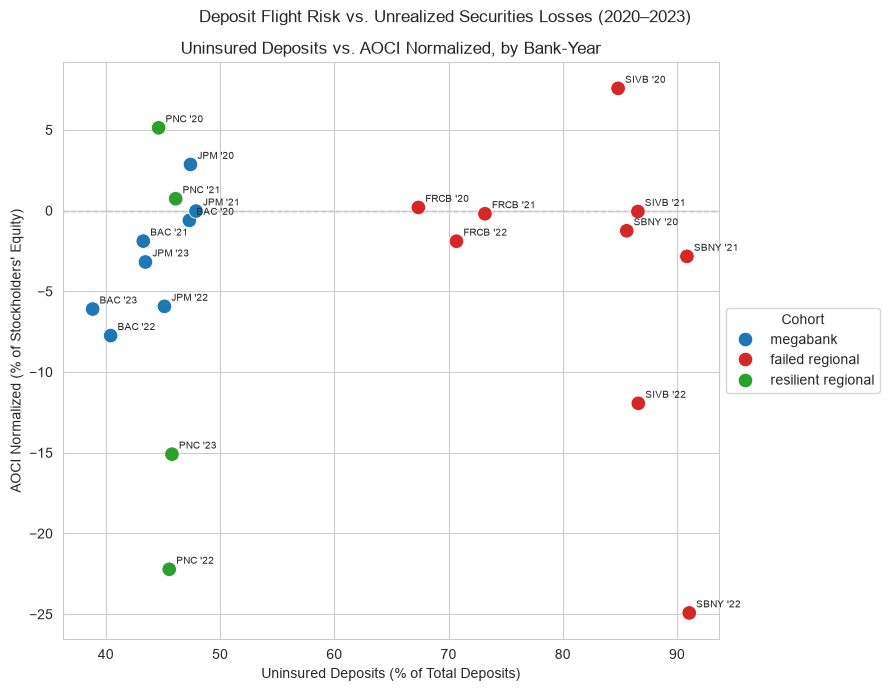

'OBSERVATION'

In [39]:
"""UNINSURED DEPOSIT % vs AOCI NORMALIZED, one point per bank per year, colored by cohort"""
scatter_df = master.dropna(subset=["uninsured_deposit_percent", "AOCI normalized"])

fig, ax = plt.subplots(1, 1, figsize=(9, 7))

sns.scatterplot(
    data=scatter_df,
    x="uninsured_deposit_percent",
    y="AOCI normalized",
    hue="cohort",
    palette=cohort_palette,
    s=110,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
)

ax.axhline(0, color="grey", linewidth=1, linestyle="--", zorder=0)

for _, row in scatter_df.iterrows():
    ax.annotate(
        f"{row['ticker']} '{str(row['year'])[2:]}",
        (row["uninsured_deposit_percent"], row["AOCI normalized"]),
        fontsize=7,
        xytext=(5, 4),
        textcoords="offset points",
    )

ax.set_title("Uninsured Deposits vs. AOCI Normalized, by Bank-Year")
ax.set_xlabel("Uninsured Deposits (% of Total Deposits)")
ax.set_ylabel("AOCI Normalized (% of Stockholders' Equity)")
ax.legend(title="Cohort", loc="center left", bbox_to_anchor=(1.0, 0.5))

fig.suptitle("Deposit Flight Risk vs. Unrealized Securities Losses (2020–2023)")
plt.tight_layout()
plt.show()

"""OBSERVATION"""
# Failed regionals cluster in the high-uninsured-deposit / negative-AOCI quadrant, exactly the combination of a flighty
# funding base and eroded capital that produced the 2023 bank runs. Megabanks and PNC sit closer to the origin, with
# less extreme uninsured deposit exposure and comparatively contained AOCI erosion.

In [40]:
master.groupby(["year", "cohort"])[["NIM", "ROA", "ROE", "ER", "uninsured_deposit_percent", "AOCI normalized"]].mean()

NIM       ROA        ROE         ER  \
year cohort                                                         
2020 failed regional     2.807374  0.833529  10.489167  50.896691   
     megabank            2.477013  0.561303   5.637500  57.967153   
     resilient regional  2.642336  0.492847   4.875000  60.751759   
2021 failed regional     2.385063  0.894683  12.132500  51.479044   
     megabank            1.889931  1.195225  13.017500  61.612859   
     resilient regional  2.233158  1.235213  12.460000  65.671524   
2022 failed regional     2.328686  0.997386  13.684167  46.553519   
     megabank            2.131449  0.946432  10.373750  59.725297   
     resilient regional  2.512512  1.026194  11.752500  64.518923   
2023 megabank            2.927772  1.392175  14.886250  51.871976   
     resilient regional  2.961171  1.147306  13.922500  59.521946   

                         uninsured_deposit_percent  AOCI normalized  
year cohort                                                          
2020 failed regional                     79.265294         2.172727  
     megabank                            47.359246         1.125988  
     resilient regional                  44.618117          5.12868  
2021 failed regional                     83.543220         -1.02869  
     megabank                            45.584968        -0.959234  
     resilient regional                  46.110276         0.734357  
2022 failed regional                     82.791785        -12.92091  
     megabank                            42.772337        -6.837908  
     resilient regional                  45.549449       -22.222222  
2023 megabank                            41.153449        -4.642101  
     resilient regional                  45.785653         -15.0905

In [66]:
"""GAP-VS-SPREAD SETUP: restrict to the balanced 2020-2022 panel (all 6 banks have data for these years)"""
gap_metrics = ["NIM", "ROA", "ROE", "ER", "uninsured_deposit_percent", "AOCI normalized", "deposit_growth_pct", "HTM unrealized loss normalized"]
gap_df = master.loc[master["year"].isin(trend_years)].copy()
gap_df["cohort"].value_counts()

cohort
failed regional       9
megabank              6
resilient regional    3
Name: count, dtype: int64

In [67]:
"""For each metric: cohort means (the 'gap'), pooled within-cohort std (the 'spread'),
and eta-squared = between-cohort variance / total variance as the single gap-vs-spread ratio."""

def gap_vs_spread(df, metric, group_col="cohort"):
    g = df.dropna(subset=[metric]).groupby(group_col)[metric]
    counts, means, variances = g.count(), g.mean(), g.var(ddof=1)
    grand_mean = df[metric].dropna().mean()

    ss_between = sum(counts[c] * (means[c] - grand_mean) ** 2 for c in counts.index)
    ss_within = sum((counts[c] - 1) * variances[c] for c in counts.index if counts[c] > 1)
    dof_within = sum(counts[c] - 1 for c in counts.index if counts[c] > 1)

    pooled_std = (ss_within / dof_within) ** 0.5 if dof_within > 0 else float("nan")
    eta_squared = ss_between / (ss_between + ss_within) if (ss_between + ss_within) > 0 else float("nan")

    row = {
        "n_total": int(counts.sum()),
        "gap_range": means.max() - means.min(),
        "pooled_within_std": pooled_std,
        "eta_squared": eta_squared,
    }
    for cohort_name in means.index:
        row[f"mean__{cohort_name}"] = means[cohort_name]
    if "failed regional" in means.index and pooled_std:
        for cohort_name in means.index:
            if cohort_name != "failed regional":
                row[f"std_gap__failed_vs_{cohort_name}"] = (means["failed regional"] - means[cohort_name]) / pooled_std
    return row

gap_spread_summary = pd.DataFrame(
    {metric: gap_vs_spread(gap_df, metric) for metric in gap_metrics}
).T
gap_spread_summary = gap_spread_summary.sort_values("eta_squared", ascending=False)
gap_spread_summary

,n_total,gap_range,pooled_within_std,eta_squared,mean__failed regional,mean__megabank,mean__resilient regional,std_gap__failed_vs_megabank,std_gap__failed_vs_resilient regional
uninsured_deposit_percent,18.0,36.627916,6.773552,0.897357,81.866766,45.238850,45.425947,5.407490,5.379868
ER,18.0,14.004317,8.711731,0.351409,49.643085,59.768436,63.647402,-1.162266,-1.607524
NIM,18.0,0.340910,0.286795,0.262679,2.507041,2.166131,2.462668,1.188687,0.154718
ROE,18.0,2.425694,3.103392,0.154193,12.101944,9.676250,9.695833,0.781627,0.775317
deposit_growth_pct,12.0,24.910779,32.222111,0.148676,29.500017,4.589238,10.285911,0.773096,0.596302
HTM unrealized loss normalized,18.0,8.939860,25.976852,0.018454,-12.346531,-8.492925,-3.406671,-0.148348,-0.344147
AOCI normalized,18.0,3.229344,8.962257,0.018427,-3.925624,-2.223718,-5.453062,-0.189897,0.170430
ROA,18.0,0.017098,0.235952,0.000718,0.908533,0.900987,0.918085,0.031980,-0.040483


**Reading this table:**
- `gap_range` = spread between the highest and lowest cohort mean (the "gap").
- `pooled_within_std` = pooled within-cohort standard deviation across the three cohorts (the "spread").
- `eta_squared` = share of total variance explained by cohort membership (0-1); higher means the
  gap is large relative to the noise inside each cohort.
- `std_gap__failed_vs_*` = how many pooled-within-cohort standard deviations separate the failed
  regional mean from the other cohort (a Cohen's-d-style number), for direct interpretability.

**Sidenote:** bank-year rows within a cohort aren't fully independent draws, multiple years from
the same bank are autocorrelated. So treat `eta_squared` and the pooled std as descriptive effect
sizes, not inferential test statistics. This is most visible for "resilient regional," where all 3
rows come from a single bank (PNC): its within-cohort spread reflects PNC's own year-to-year
variation, not variation across banks, unlike the other two cohorts.

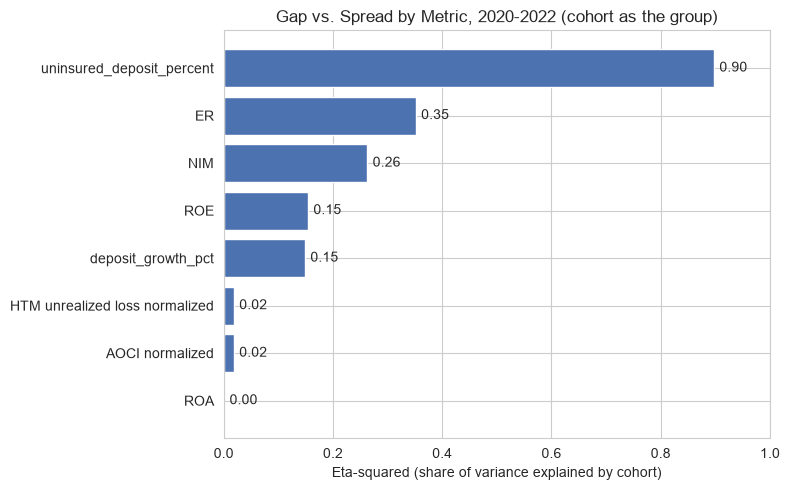

In [68]:
"""ETA-SQUARED BY METRIC — how much of each metric's variance is explained by cohort, relative to noise"""
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
plot_order = gap_spread_summary.sort_values("eta_squared")
ax.barh(plot_order.index, plot_order["eta_squared"], color="#4c72b0")
ax.set_xlabel("Eta-squared (share of variance explained by cohort)")
ax.set_title("Gap vs. Spread by Metric, 2020-2022 (cohort as the group)")
ax.set_xlim(0, 1)
for y, val in enumerate(plot_order["eta_squared"]):
    ax.text(val + 0.01, y, f"{val:.2f}", va="center")
plt.tight_layout()
plt.show()

In [44]:
"""BOOTSTRAP CI ON COHORT-MEAN GAPS -- NIM and AOCI normalized (2020-2022 balanced panel)"""
import numpy as np

rng = np.random.default_rng(42)
n_boot = 5000
bootstrap_metrics = ["NIM", "AOCI normalized"]
other_cohorts = ["megabank", "resilient regional"]

def bootstrap_gap(df, metric, cohort_a, cohort_b, n_boot=5000, rng=rng):
    a = df.loc[df["cohort"] == cohort_a, metric].dropna().to_numpy()
    b = df.loc[df["cohort"] == cohort_b, metric].dropna().to_numpy()
    gaps = np.empty(n_boot)
    for k in range(n_boot):
        gaps[k] = rng.choice(a, size=len(a), replace=True).mean() - rng.choice(b, size=len(b), replace=True).mean()
    point = a.mean() - b.mean()
    lo, hi = np.percentile(gaps, [2.5, 97.5])
    return point, lo, hi

bootstrap_rows = []
for metric in bootstrap_metrics:
    for other in other_cohorts:
        point, lo, hi = bootstrap_gap(gap_df, metric, "failed regional", other, n_boot=n_boot)
        bootstrap_rows.append({
            "metric": metric,
            "comparison": f"failed regional vs. {other}",
            "gap": point,
            "ci_low": lo,
            "ci_high": hi,
        })

bootstrap_summary = pd.DataFrame(bootstrap_rows)
bootstrap_summary


,metric,comparison,gap,ci_low,ci_high
0,NIM,failed regional vs. megabank,0.340910,0.061944,0.617952
1,NIM,failed regional vs. resilient regional,0.044372,-0.219912,0.315292
2,AOCI normalized,failed regional vs. megabank,-1.701906,-8.669826,4.277521
3,AOCI normalized,failed regional vs. resilient regional,1.527437,-11.370515,17.204641


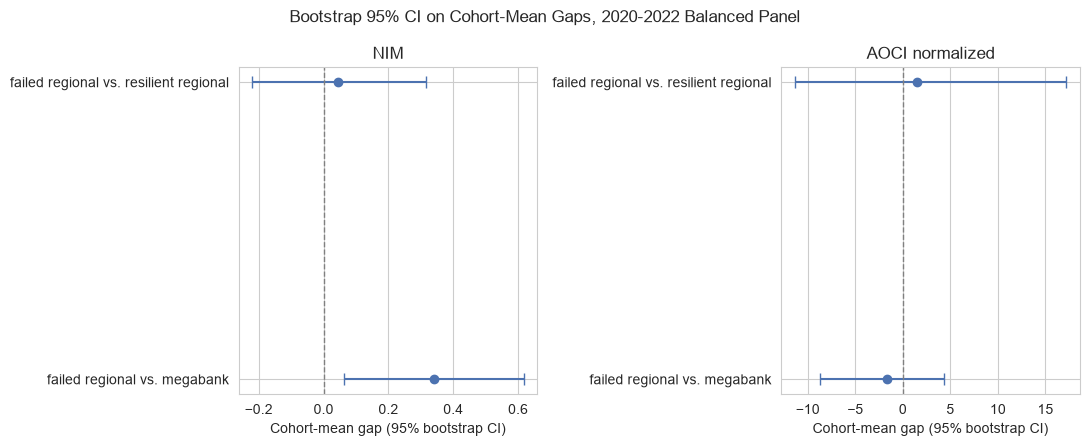

In [45]:
"""BOOTSTRAP CI CHART -- cohort-mean gap (failed regional vs. other cohorts), NIM and AOCI normalized"""
fig, axes = plt.subplots(1, len(bootstrap_metrics), figsize=(11, 4.5), sharey=False)

for ax, metric in zip(axes, bootstrap_metrics):
    plot_df = bootstrap_summary.loc[bootstrap_summary["metric"] == metric]
    y_pos = range(len(plot_df))
    err_low = plot_df["gap"] - plot_df["ci_low"]
    err_high = plot_df["ci_high"] - plot_df["gap"]
    ax.errorbar(plot_df["gap"], y_pos, xerr=[err_low, err_high], fmt="o", color="#4c72b0", capsize=4)
    ax.axvline(0, color="grey", linewidth=1, linestyle="--")
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(plot_df["comparison"])
    ax.set_title(metric)
    ax.set_xlabel("Cohort-mean gap (95% bootstrap CI)")

fig.suptitle("Bootstrap 95% CI on Cohort-Mean Gaps, 2020-2022 Balanced Panel")
plt.tight_layout()
plt.show()


**Caveat:** this bootstrap resamples bank-years *within* each cohort as if they were
independent draws. That doesn't fix the autocorrelation problem noted in the
eta-squared section above -- e.g. "resilient regional" is still 3 years of one bank
(PNC), so its resampled draws are still just PNC's own year-to-year variation, not
variation across banks. Read these intervals as a precision check on the *within-data*
gap, not as proof the gap would replicate across a larger sample of banks.

In [46]:
"""QUARTERLY ANALYSIS"""
# Preparing the dataframe for analysis and adding useful metrics, have not been added yet to the quarterly data
quarterly_metrics["quarter"] = quarterly_metrics["Date"].dt.month.map(lambda x: "Q1" if x == 3 else "Q2" if x == 6 else "Q3" if x == 9 else "Q4")

cohort_map = {
    "BAC": "megabank",
    "JPM": "megabank",
    "PNC": "resilient regional",
    "SIVB": "failed regional",
    "FRCB": "failed regional",
    "SBNY": "failed regional"
}

quarterly_metrics["cohort"] = quarterly_metrics["Name"].map(cohort_map)

**QUARTERLY ANALYSIS**

To get a better understanding of **when** the threat of potential bank failure became a detectable risk, we need to zoom in on the quarterly Call Report data.

In [47]:
quarterly_metrics

,Name,Date,NIM,ROA,ROE,ER,uninsured_deposit_percent,Year,quarter,cohort
0,BAC,2023-12-31,2.711316,1.161318,12.48,56.536964,39.060449,2023,Q4,megabank
1,BAC,2023-09-30,2.763051,1.309557,14.07,52.988741,38.506888,2023,Q3,megabank
2,BAC,2023-06-30,2.776728,1.314678,14.12,52.871228,38.656946,2023,Q2,megabank
3,BAC,2023-03-31,2.806533,1.343057,14.48,52.538521,39.144460,2023,Q1,megabank
4,BAC,2022-12-31,2.434248,1.114429,11.91,56.228497,40.425804,2022,Q4,megabank
...,...,...,...,...,...,...,...,...,...,...
80,SIVB,2021-03-31,2.202224,0.891432,14.30,54.428274,86.306627,2021,Q1,failed regional
81,SIVB,2020-12-31,2.607218,0.945171,13.94,55.567263,85.820325,2020,Q4,failed regional
82,SIVB,2020-09-30,2.725883,0.962121,13.78,51.932761,85.851187,2020,Q3,failed regional
83,SIVB,2020-06-30,2.881189,0.849732,11.76,49.634132,84.620960,2020,Q2,failed regional


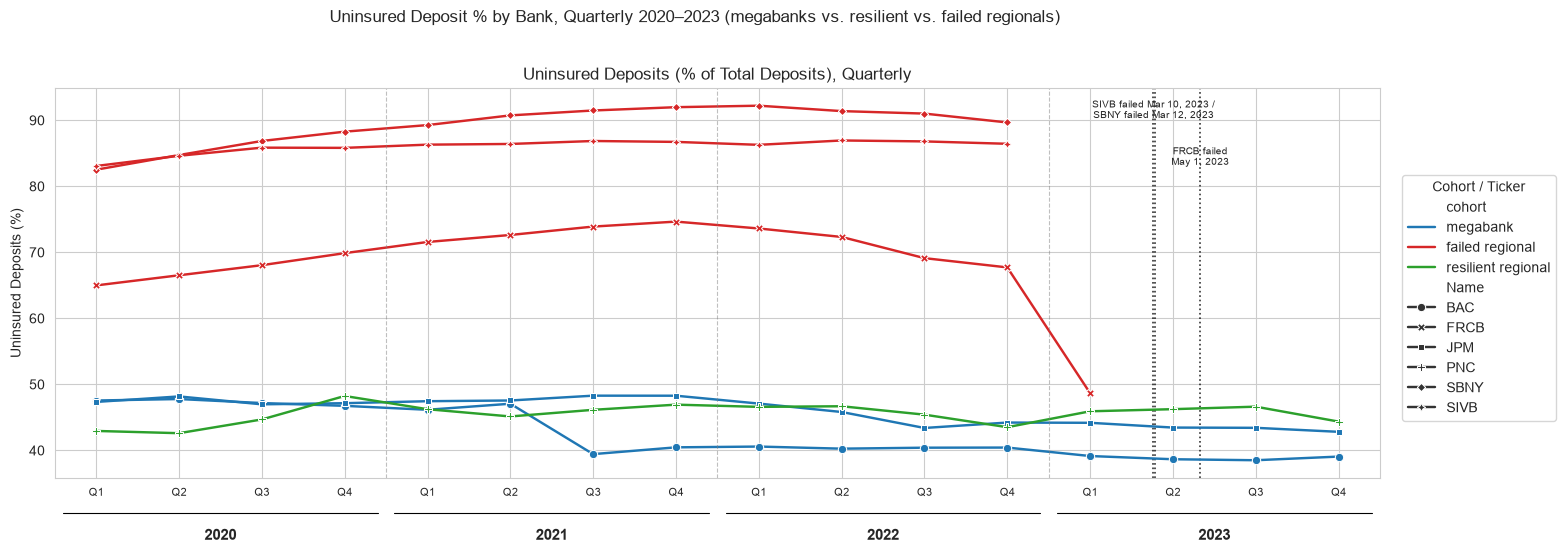

In [48]:
"""UNINSURED DEPOSIT % TRENDS (QUARTERLY), by bank, colored by cohort, with a multi-level (quarter/year) x-axis"""
# Chronological ordering of every Year-Quarter period present in the data, mapped to a single numeric x position
period_order = (
    quarterly_metrics[["Year", "quarter"]]
    .drop_duplicates()
    .assign(quarter_num=lambda d: d["quarter"].str[1].astype(int))
    .sort_values(["Year", "quarter_num"])
    .reset_index(drop=True)
)
period_order["x"] = period_order.index
period_to_x = period_order.set_index(["Year", "quarter"])["x"]

quarterly_metrics["x"] = quarterly_metrics.set_index(["Year", "quarter"]).index.map(period_to_x)

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

sns.lineplot(
    data=quarterly_metrics,
    x="x",
    y="uninsured_deposit_percent",
    hue="cohort",
    style="Name",
    palette=cohort_palette,
    markers=True,
    dashes=False,
    markersize=6,
    linewidth=1.75,
    ax=ax,
)

ax.set_title("Uninsured Deposits (% of Total Deposits), Quarterly")
ax.set_xlabel("")
ax.set_ylabel("Uninsured Deposits (%)")

# --- Level 1: quarter ticks ---
ax.set_xticks(period_order["x"])
ax.set_xticklabels(period_order["quarter"], fontsize=8)
ax.set_xlim(-0.5, period_order["x"].max() + 0.5)

# --- Level 2: year labels centered under each group of quarters, with a bracket line ---
year_groups = period_order.groupby("Year")["x"].agg(["min", "max"])
trans = ax.get_xaxis_transform()  # x in data coords, y in axes (0-1) coords

for year, row in year_groups.iterrows():
    center = (row["min"] + row["max"]) / 2
    ax.plot(
        [row["min"] - 0.4, row["max"] + 0.4], [-0.09, -0.09],
        transform=trans, color="black", linewidth=0.8, clip_on=False,
    )
    ax.text(center, -0.13, str(year), transform=trans, ha="center", va="top", fontsize=11, fontweight="bold")

# vertical separators between years
for year, row in year_groups.iloc[1:].iterrows():
    ax.axvline(row["min"] - 0.5, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)

# --- Approximate bank failure dates, as vertical reference lines ---
failure_dates = {
    "SIVB": pd.Timestamp("2023-03-10"),
    "SBNY": pd.Timestamp("2023-03-12"),
    "FRCB": pd.Timestamp("2023-05-01"),
}

def date_to_x(date):
    period = date.to_period("Q")
    q_start, q_end = period.start_time, period.end_time
    frac = (date - q_start) / (q_end - q_start)
    return period_to_x[(period.year, f"Q{period.quarter}")] + frac

failure_x = {ticker: date_to_x(date) for ticker, date in failure_dates.items()}

for x_pos in failure_x.values():
    ax.axvline(x_pos, color="black", linewidth=1.2, linestyle=":", alpha=0.8, zorder=1)

# SIVB and SBNY failed two days apart, so their lines sit almost on top of
# each other -- one combined label avoids overlapping text.
ax.text(
    (failure_x["SIVB"] + failure_x["SBNY"]) / 2, 0.97,
    "SIVB failed Mar 10, 2023 /\nSBNY failed Mar 12, 2023",
    transform=trans, ha="center", va="top", fontsize=7,
)
ax.text(
    failure_x["FRCB"], 0.85,
    "FRCB failed\nMay 1, 2023",
    transform=trans, ha="center", va="top", fontsize=7,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), title="Cohort / Ticker")

fig.suptitle("Uninsured Deposit % by Bank, Quarterly 2020–2023 (megabanks vs. resilient vs. failed regionals)")
plt.tight_layout()
plt.subplots_adjust(bottom=0.2, top=0.85)
plt.show()

**UNINSURED DEPOSIT % BY BANK**

The more detailed view confirms that the high % of uninsured deposits was not a recent development at the time of the banks' failure, and instead a product of long term policy. Interestingly, with the data available, we can see the First Republic Bank try to correct it's overextended capital in Q1 of 2023, unfortunately with little success - apart from being the last one to fail.

In [49]:
# Creating a 10-Q quarterly dataframe.
quarterly_data = pd.read_parquet("data/processed/processed_dataframes/DataframeLongQuarterly.parquet")

# Assigning tickers to company names for more readability and easier JOINs.
bank_tickers = {
    "BANK OF AMERICA CORP": "BAC",
    "First Republic Bank": "FRCB",
    "JPMORGAN CHASE & CO": "JPM",
    "PNC FINANCIAL SERVICES GROUP, INC.": "PNC",
    "Signature Bank": "SBNY",
    "SVB Financial Group": "SIVB",
}
quarterly_data["ticker"] = quarterly_data["company_name"].map(bank_tickers)

# Filtering and Cleaning.
quarterly_data = quarterly_data.loc[(quarterly_data["year"] >= 2022)] # filtering to recent (2022 to 2023) scope
quarterly_data = quarterly_data.reset_index()
quarterly_data = quarterly_data.drop(columns=["index"]) # dropping leftover column


In [50]:
# creating a multiindex (10-Q data) that will be joined with quarterly_metrics (Call reports).
quarterly_data_pivot = quarterly_data.pivot_table(
    index=["ticker", "year", "quarter"],
    columns=["metric"],
    values="value_usd"
)

# fixing numbers displaying in scientific notation
for column in quarterly_data_pivot.columns:
    quarterly_data_pivot[column] = quarterly_data_pivot[column].astype("Int64")

# Final join between quarterly Call Reports and 10-Q data
quarterly_metrics = quarterly_metrics.drop(columns="x")
quarterly_metrics = quarterly_metrics.rename(columns={"Name": "ticker"})
quarterly_metrics = quarterly_metrics.rename(columns={"Year": "year"})

quarterly_metrics = quarterly_metrics.drop(columns="Date")
quarterly_complete = pd.merge(quarterly_data_pivot, quarterly_metrics, on=["ticker", "year", "quarter"])


In [51]:
quarterly_complete

,ticker,year,quarter,accumulated_other_comprehensive_income_loss,held_to_maturity_securities,held_to_maturity_securities_fair_value,interest_expense_deposits,interest_income,interest_income_plus_noninterest_income,net_income,...,noninterest_income,stockholders_equity,total_assets,total_deposits_consolidated,NIM,ROA,ROE,ER,uninsured_deposit_percent,cohort
0,BAC,2022,Q1,-13417000000,<NA>,<NA>,164000000,12894000000,24550000000,7067000000,...,11656000000,266617000000,3238223000000,2072409000000,2.014981,0.926657,10.01,62.144446,40.578043,megabank
1,BAC,2022,Q2,-16674000000,<NA>,<NA>,320000000,14975000000,25219000000,6247000000,...,10244000000,266617000000,3111606000000,1984349000000,2.139513,0.934704,10.03,61.655439,40.259262,megabank
2,BAC,2022,Q3,-21027000000,<NA>,<NA>,1235000000,19621000000,30358000000,7082000000,...,10737000000,269118000000,3072953000000,1938097000000,2.299658,1.034842,11.05,58.333783,40.406993,megabank
3,BAC,2022,Q4,-21156000000,632825000000,524267000000,2999000000,25075000000,34926000000,7132000000,...,9851000000,273197000000,3051375000000,1930341000000,2.434248,1.114429,11.91,56.228497,40.425804,megabank
4,BAC,2023,Q1,-18527000000,<NA>,<NA>,4314000000,28655000000,40465000000,8161000000,...,11810000000,280196000000,3194657000000,1910402000000,2.806533,1.343057,14.48,52.538521,39.144460,megabank
5,BAC,2023,Q2,-20742000000,<NA>,<NA>,5785000000,32354000000,43393000000,7408000000,...,11039000000,280196000000,3123198000000,1877209000000,2.776728,1.314678,14.12,52.871228,38.656946,megabank
6,BAC,2023,Q3,-21792000000,<NA>,<NA>,7340000000,33624000000,44412000000,7802000000,...,10788000000,283319000000,3153090000000,1884601000000,2.763051,1.309557,14.07,52.988741,38.506888,megabank
7,BAC,2023,Q4,-17788000000,594555000000,496597000000,8724000000,35629000000,43642000000,3144000000,...,8013000000,291646000000,3180151000000,1923827000000,2.711316,1.161318,12.48,56.536964,39.060449,megabank
8,FRCB,2022,Q1,-137000000,<NA>,<NA>,20000000,1189000000,1440000000,401000000,...,251000000,16154000000,3850000000,7042000000,2.628299,0.871920,10.02,61.614339,73.609045,failed regional
9,FRCB,2022,Q2,-227000000,<NA>,<NA>,37000000,1316000000,1579000000,433000000,...,263000000,16426000000,197908000000,165647000000,2.681357,0.883997,10.32,60.808093,72.327335,failed regional


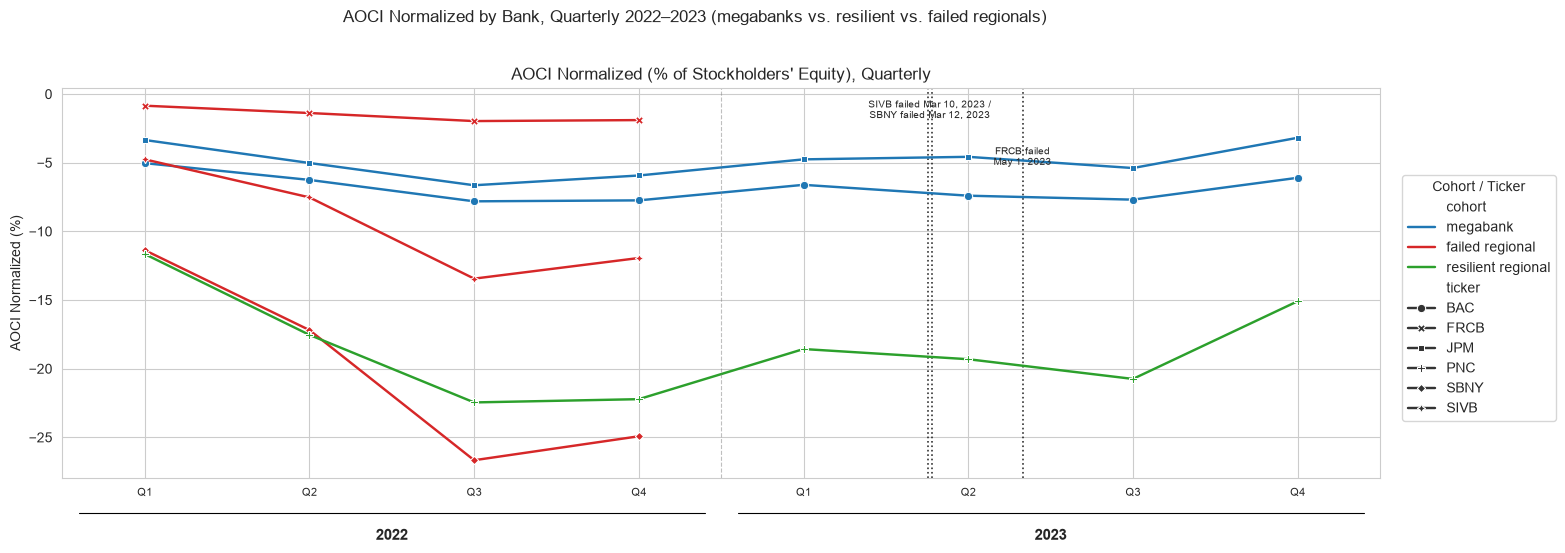

In [52]:
"""AOCI NORMALIZED TRENDS (QUARTERLY), by bank, colored by cohort, with a multi-level (quarter/year) x-axis"""

quarterly_complete["AOCI normalized"] = (
    quarterly_complete["accumulated_other_comprehensive_income_loss"] / quarterly_complete["stockholders_equity"]
) * 100

# Chronological ordering of every Year-Quarter period present in the data, mapped to a single numeric x position
period_order = (
    quarterly_complete[["year", "quarter"]]
    .drop_duplicates()
    .assign(quarter_num=lambda d: d["quarter"].str[1].astype(int))
    .sort_values(["year", "quarter_num"])
    .reset_index(drop=True)
)
period_order["x"] = period_order.index
period_to_x = period_order.set_index(["year", "quarter"])["x"]

quarterly_complete["x"] = quarterly_complete.set_index(["year", "quarter"]).index.map(period_to_x)

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

sns.lineplot(
    data=quarterly_complete,
    x="x",
    y="AOCI normalized",
    hue="cohort",
    style="ticker",
    palette=cohort_palette,
    markers=True,
    dashes=False,
    markersize=6,
    linewidth=1.75,
    ax=ax,
)

ax.set_title("AOCI Normalized (% of Stockholders' Equity), Quarterly")
ax.set_xlabel("")
ax.set_ylabel("AOCI Normalized (%)")

# --- Level 1: quarter ticks ---
ax.set_xticks(period_order["x"])
ax.set_xticklabels(period_order["quarter"], fontsize=8)
ax.set_xlim(-0.5, period_order["x"].max() + 0.5)

# --- Level 2: year labels centered under each group of quarters, with a bracket line ---
year_groups = period_order.groupby("year")["x"].agg(["min", "max"])
trans = ax.get_xaxis_transform()  # x in data coords, y in axes (0-1) coords

for year, row in year_groups.iterrows():
    center = (row["min"] + row["max"]) / 2
    ax.plot(
        [row["min"] - 0.4, row["max"] + 0.4], [-0.09, -0.09],
        transform=trans, color="black", linewidth=0.8, clip_on=False,
    )
    ax.text(center, -0.13, str(year), transform=trans, ha="center", va="top", fontsize=11, fontweight="bold")

# vertical separators between years
for year, row in year_groups.iloc[1:].iterrows():
    ax.axvline(row["min"] - 0.5, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)

# --- Approximate bank failure dates, as vertical reference lines ---
failure_dates = {
    "SIVB": pd.Timestamp("2023-03-10"),
    "SBNY": pd.Timestamp("2023-03-12"),
    "FRCB": pd.Timestamp("2023-05-01"),
}

def date_to_x(date):
    period = date.to_period("Q")
    q_start, q_end = period.start_time, period.end_time
    frac = (date - q_start) / (q_end - q_start)
    return period_to_x[(period.year, f"Q{period.quarter}")] + frac

failure_x = {ticker: date_to_x(date) for ticker, date in failure_dates.items()}

for x_pos in failure_x.values():
    ax.axvline(x_pos, color="black", linewidth=1.2, linestyle=":", alpha=0.8, zorder=1)

# SIVB and SBNY failed two days apart, so their lines sit almost on top of
# each other -- one combined label avoids overlapping text.
ax.text(
    (failure_x["SIVB"] + failure_x["SBNY"]) / 2, 0.97,
    "SIVB failed Mar 10, 2023 /\nSBNY failed Mar 12, 2023",
    transform=trans, ha="center", va="top", fontsize=7,
)
ax.text(
    failure_x["FRCB"], 0.85,
    "FRCB failed\nMay 1, 2023",
    transform=trans, ha="center", va="top", fontsize=7,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), title="Cohort / Ticker")

fig.suptitle("AOCI Normalized by Bank, Quarterly 2022–2023 (megabanks vs. resilient vs. failed regionals)")
plt.tight_layout()
plt.subplots_adjust(bottom=0.2, top=0.85)
plt.show()


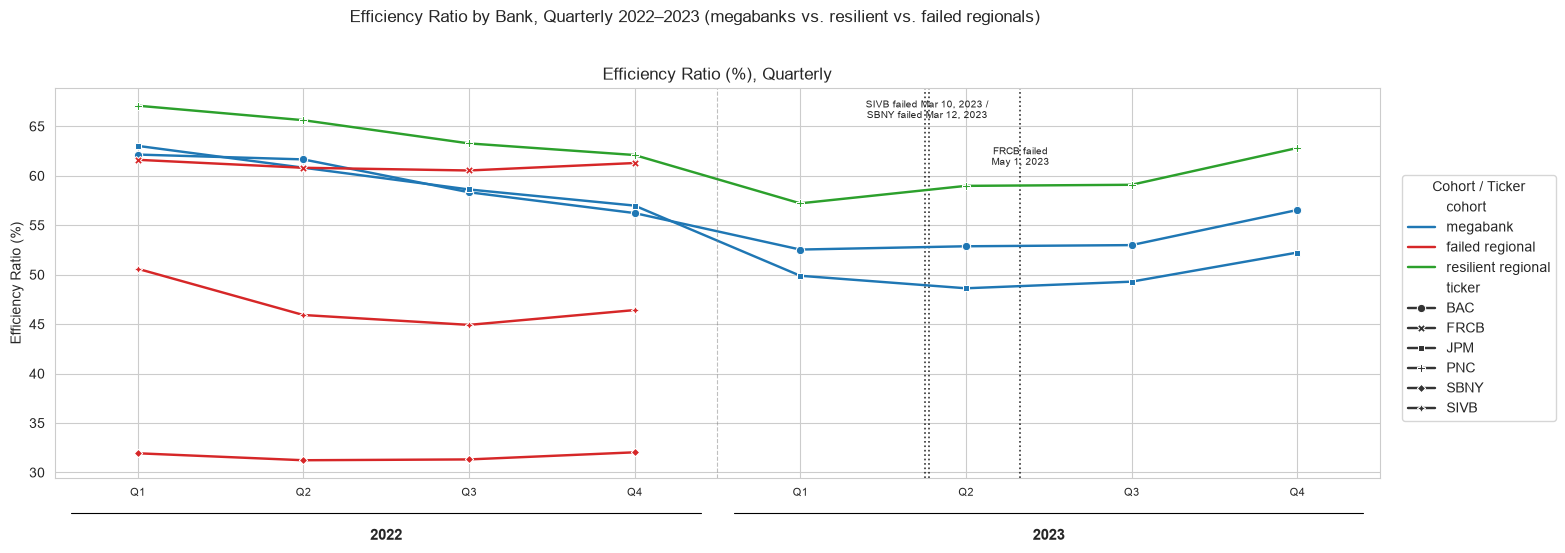

In [53]:
"""EFFICIENCY RATIO TRENDS (QUARTERLY), by bank, colored by cohort, with a multi-level (quarter/year) x-axis"""

# Chronological ordering of every Year-Quarter period present in the data, mapped to a single numeric x position
period_order = (
    quarterly_complete[["year", "quarter"]]
    .drop_duplicates()
    .assign(quarter_num=lambda d: d["quarter"].str[1].astype(int))
    .sort_values(["year", "quarter_num"])
    .reset_index(drop=True)
)
period_order["x"] = period_order.index
period_to_x = period_order.set_index(["year", "quarter"])["x"]

quarterly_complete["x"] = quarterly_complete.set_index(["year", "quarter"]).index.map(period_to_x)

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

sns.lineplot(
    data=quarterly_complete,
    x="x",
    y="ER",
    hue="cohort",
    style="ticker",
    palette=cohort_palette,
    markers=True,
    dashes=False,
    markersize=6,
    linewidth=1.75,
    ax=ax,
)

ax.set_title("Efficiency Ratio (%), Quarterly")
ax.set_xlabel("")
ax.set_ylabel("Efficiency Ratio (%)")

# --- Level 1: quarter ticks ---
ax.set_xticks(period_order["x"])
ax.set_xticklabels(period_order["quarter"], fontsize=8)
ax.set_xlim(-0.5, period_order["x"].max() + 0.5)

# --- Level 2: year labels centered under each group of quarters, with a bracket line ---
year_groups = period_order.groupby("year")["x"].agg(["min", "max"])
trans = ax.get_xaxis_transform()  # x in data coords, y in axes (0-1) coords

for year, row in year_groups.iterrows():
    center = (row["min"] + row["max"]) / 2
    ax.plot(
        [row["min"] - 0.4, row["max"] + 0.4], [-0.09, -0.09],
        transform=trans, color="black", linewidth=0.8, clip_on=False,
    )
    ax.text(center, -0.13, str(year), transform=trans, ha="center", va="top", fontsize=11, fontweight="bold")

# vertical separators between years
for year, row in year_groups.iloc[1:].iterrows():
    ax.axvline(row["min"] - 0.5, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)

# --- Approximate bank failure dates, as vertical reference lines ---
failure_dates = {
    "SIVB": pd.Timestamp("2023-03-10"),
    "SBNY": pd.Timestamp("2023-03-12"),
    "FRCB": pd.Timestamp("2023-05-01"),
}

def date_to_x(date):
    period = date.to_period("Q")
    q_start, q_end = period.start_time, period.end_time
    frac = (date - q_start) / (q_end - q_start)
    return period_to_x[(period.year, f"Q{period.quarter}")] + frac

failure_x = {ticker: date_to_x(date) for ticker, date in failure_dates.items()}

for x_pos in failure_x.values():
    ax.axvline(x_pos, color="black", linewidth=1.2, linestyle=":", alpha=0.8, zorder=1)

# SIVB and SBNY failed two days apart, so their lines sit almost on top of
# each other -- one combined label avoids overlapping text.
ax.text(
    (failure_x["SIVB"] + failure_x["SBNY"]) / 2, 0.97,
    "SIVB failed Mar 10, 2023 /\nSBNY failed Mar 12, 2023",
    transform=trans, ha="center", va="top", fontsize=7,
)
ax.text(
    failure_x["FRCB"], 0.85,
    "FRCB failed\nMay 1, 2023",
    transform=trans, ha="center", va="top", fontsize=7,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), title="Cohort / Ticker")

fig.suptitle("Efficiency Ratio by Bank, Quarterly 2022\u20132023 (megabanks vs. resilient vs. failed regionals)")
plt.tight_layout()
plt.subplots_adjust(bottom=0.2, top=0.85)
plt.show()


In [54]:
quarterly_complete.columns

Index(['ticker', 'year', 'quarter',
       'accumulated_other_comprehensive_income_loss',
       'held_to_maturity_securities', 'held_to_maturity_securities_fair_value',
       'interest_expense_deposits', 'interest_income',
       'interest_income_plus_noninterest_income', 'net_income',
       'net_interest_income', 'noninterest_expense', 'noninterest_income',
       'stockholders_equity', 'total_assets', 'total_deposits_consolidated',
       'NIM', 'ROA', 'ROE', 'ER', 'uninsured_deposit_percent', 'cohort',
       'AOCI normalized', 'x'],
      dtype='str')

## Deposit Beta (Quarterly)

How much of the Fed's 2022-2023 hiking cycle did each bank pass on to its depositors, rather than absorb into its own margin? deposit_beta measures the change in a bank's annualized cost of deposits per unit change in the Effective Fed Funds Rate, cumulative since **Q4 2021** - the last full quarter before the hiking cycle began in March 2022.

- **Cost of deposits** = (quarterly interest_expense_deposits x 4) / average total deposits (mean of the current and prior quarter-end total_deposits_consolidated balance), annualized to a %.
- **Deposit beta** = (cost_of_deposits - cost_of_deposits at the Q4 2021 baseline) / (fed_funds_rate - fed_funds_rate at the Q4 2021 baseline), per bank per quarter.

In [55]:
"""FED FUNDS RATE (quarterly average) -- the deposit-beta benchmark rate"""
fed_funds = pd.read_csv("data/raw/fred/DFF.csv", parse_dates=["observation_date"])
fed_funds = fed_funds.set_index("observation_date")["DFF"].resample("QE").mean().reset_index()
fed_funds["year"] = fed_funds["observation_date"].dt.year
fed_funds["quarter"] = "Q" + fed_funds["observation_date"].dt.quarter.astype(str)
fed_funds_quarterly = fed_funds[["year", "quarter", "DFF"]].rename(columns={"DFF": "fed_funds_rate"})
fed_funds_quarterly

,year,quarter,fed_funds_rate
0,2020,Q1,1.254945
1,2020,Q2,0.058791
2,2020,Q3,0.092609
3,2020,Q4,0.088804
4,2021,Q1,0.076889
5,2021,Q2,0.068242
6,2021,Q3,0.090000
7,2021,Q4,0.079457
8,2022,Q1,0.121444
9,2022,Q2,0.766813


In [56]:
"""COST OF DEPOSITS (quarterly, annualized %), 2021-2023 -- full range needed for the Q4 2021 baseline"""
deposit_beta_source = pd.read_parquet("data/processed/processed_dataframes/DataframeLongQuarterly.parquet")
deposit_beta_source["ticker"] = deposit_beta_source["company_name"].map(bank_tickers)

deposit_beta_pivot = deposit_beta_source.pivot_table(
    index=["ticker", "year", "quarter"],
    columns="metric",
    values="value_usd",
)[["interest_expense_deposits", "total_deposits_consolidated"]].reset_index()

deposit_beta_pivot["quarter_num"] = deposit_beta_pivot["quarter"].str[1].astype(int)
deposit_beta_pivot = deposit_beta_pivot.sort_values(["ticker", "year", "quarter_num"]).reset_index(drop=True)

# Average of the current and prior quarter-end deposit balance, in chronological
# (not same-year) order -- Q1's "prior quarter" is the previous year's Q4.
deposit_beta_pivot["avg_total_deposits"] = (
    deposit_beta_pivot["total_deposits_consolidated"] +
    deposit_beta_pivot.groupby("ticker")["total_deposits_consolidated"].shift()
) / 2

deposit_beta_pivot["cost_of_deposits"] = (
    deposit_beta_pivot["interest_expense_deposits"] * 4 / deposit_beta_pivot["avg_total_deposits"]
) * 100

deposit_beta_pivot["cohort"] = deposit_beta_pivot["ticker"].map(cohort_map)
deposit_beta_pivot[["interest_expense_deposits", "total_deposits_consolidated", "avg_total_deposits"]] = (
    deposit_beta_pivot[["interest_expense_deposits", "total_deposits_consolidated", "avg_total_deposits"]].astype("Int64"))
deposit_beta_pivot

metric,ticker,year,quarter,interest_expense_deposits,total_deposits_consolidated,quarter_num,avg_total_deposits,cost_of_deposits,cohort
0,BAC,2021,Q1,133000000,1884938000000,1,<NA>,NaN,megabank
1,BAC,2021,Q2,128000000,1909142000000,2,1897040000000,0.026989,megabank
2,BAC,2021,Q3,133000000,1964804000000,3,1936973000000,0.027466,megabank
3,BAC,2021,Q4,143000000,2064446000000,4,2014625000000,0.028392,megabank
4,BAC,2022,Q1,164000000,2072409000000,1,2068427500000,0.031715,megabank
5,BAC,2022,Q2,320000000,1984349000000,2,2028379000000,0.063105,megabank
6,BAC,2022,Q3,1235000000,1938097000000,3,1961223000000,0.251884,megabank
7,BAC,2022,Q4,2999000000,1930341000000,4,1934219000000,0.620199,megabank
8,BAC,2023,Q1,4314000000,1910402000000,1,1920371500000,0.898576,megabank
9,BAC,2023,Q2,5785000000,1877209000000,2,1893805500000,1.221878,megabank


In [57]:
"""DEPOSIT BETA -- cumulative since the Q4 2021 pre-hike baseline, per bank per quarter"""
deposit_beta_df = pd.merge(deposit_beta_pivot, fed_funds_quarterly, on=["year", "quarter"], how="left")

baseline = deposit_beta_df.loc[
    (deposit_beta_df["year"] == 2021) & (deposit_beta_df["quarter"] == "Q4"),
    ["ticker", "cost_of_deposits", "fed_funds_rate"],
].rename(columns={"cost_of_deposits": "baseline_cost_of_deposits", "fed_funds_rate": "baseline_fed_funds_rate"})

deposit_beta_df = pd.merge(deposit_beta_df, baseline, on="ticker", how="left")
deposit_beta_df["deposit_beta"] = (
    (deposit_beta_df["cost_of_deposits"] - deposit_beta_df["baseline_cost_of_deposits"]) /
    (deposit_beta_df["fed_funds_rate"] - deposit_beta_df["baseline_fed_funds_rate"])
)

deposit_beta_df = deposit_beta_df.loc[
    (deposit_beta_df["year"] > 2021) & deposit_beta_df["cost_of_deposits"].notna()
]

deposit_beta_final = deposit_beta_df[
    ["ticker", "year", "quarter", "cost_of_deposits", "deposit_beta"]
].reset_index(drop=True)
deposit_beta_final

,ticker,year,quarter,cost_of_deposits,deposit_beta
0,BAC,2022,Q1,0.031715,0.079131
1,BAC,2022,Q2,0.063105,0.050501
2,BAC,2022,Q3,0.251884,0.106248
3,BAC,2022,Q4,0.620199,0.165591
4,BAC,2023,Q1,0.898576,0.196204
5,BAC,2023,Q2,1.221878,0.243138
6,BAC,2023,Q3,1.560951,0.295873
7,BAC,2023,Q4,1.832567,0.343617
8,FRCB,2022,Q1,0.097941,1.011039
9,FRCB,2022,Q2,0.171406,0.168641


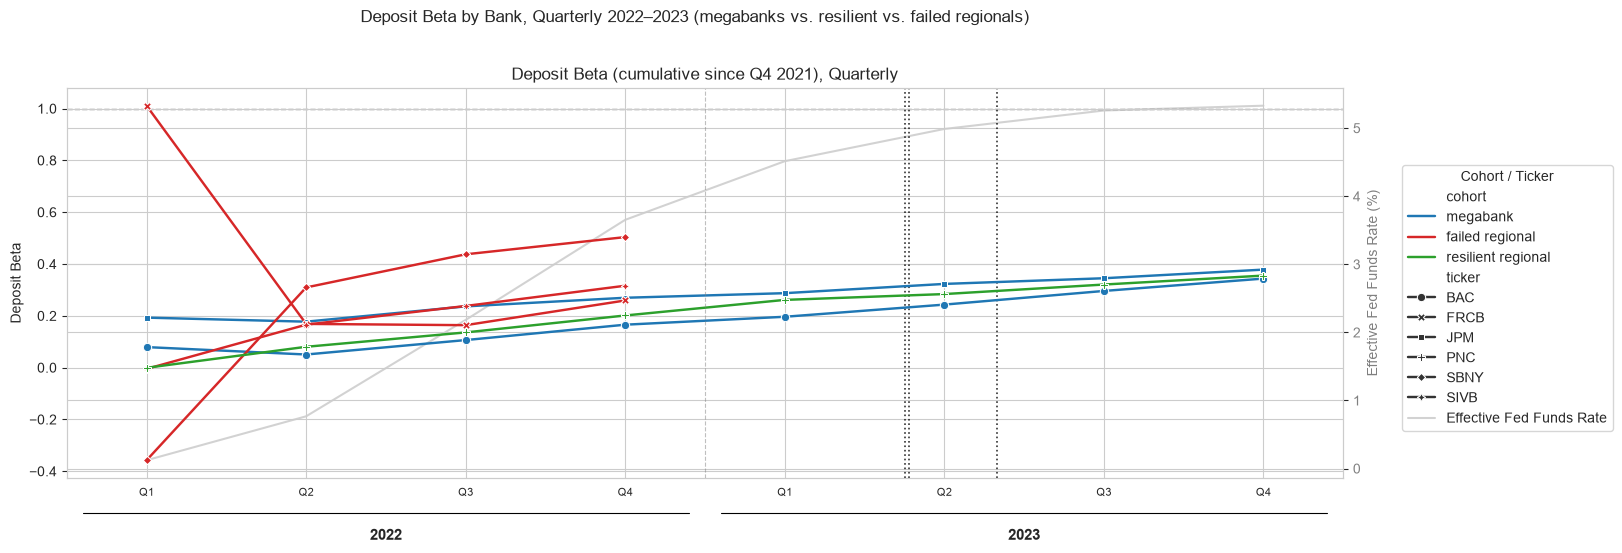

In [58]:
"""DEPOSIT BETA TRENDS (QUARTERLY), by bank, colored by cohort, with a multi-level (quarter/year) x-axis"""
deposit_beta_chart = pd.merge(deposit_beta_final, deposit_beta_pivot[["ticker", "year", "quarter", "cohort"]],
                               on=["ticker", "year", "quarter"], how="left")

period_order = (
    deposit_beta_chart[["year", "quarter"]]
    .drop_duplicates()
    .assign(quarter_num=lambda d: d["quarter"].str[1].astype(int))
    .sort_values(["year", "quarter_num"])
    .reset_index(drop=True)
)
period_order["x"] = period_order.index
period_to_x = period_order.set_index(["year", "quarter"])["x"]

deposit_beta_chart["x"] = deposit_beta_chart.set_index(["year", "quarter"]).index.map(period_to_x)

fed_funds_chart = pd.merge(
    fed_funds_quarterly, period_order[["year", "quarter", "x"]], on=["year", "quarter"], how="inner"
).sort_values("x")

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Secondary right-hand axis for the Fed Funds Rate helper line -- drawn behind
# the main axes (ax raised above ax2, ax's own background hidden) so it reads
# as a subtle backdrop rather than competing with the per-bank series.
ax2 = ax.twinx()
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)

ax2.plot(
    fed_funds_chart["x"], fed_funds_chart["fed_funds_rate"],
    color="grey", alpha=0.35, linewidth=1.5, zorder=0,
    label="Effective Fed Funds Rate",
)
ax2.set_ylabel("Effective Fed Funds Rate (%)", color="grey")
ax2.tick_params(axis="y", labelcolor="grey")

sns.lineplot(
    data=deposit_beta_chart,
    x="x",
    y="deposit_beta",
    hue="cohort",
    style="ticker",
    palette=cohort_palette,
    markers=True,
    dashes=False,
    markersize=6,
    linewidth=1.75,
    ax=ax,
)

ax.axhline(1, color="grey", linewidth=1, linestyle="--", zorder=0)
ax.set_title("Deposit Beta (cumulative since Q4 2021), Quarterly")
ax.set_xlabel("")
ax.set_ylabel("Deposit Beta")

ax.set_xticks(period_order["x"])
ax.set_xticklabels(period_order["quarter"], fontsize=8)
ax.set_xlim(-0.5, period_order["x"].max() + 0.5)

year_groups = period_order.groupby("year")["x"].agg(["min", "max"])
trans = ax.get_xaxis_transform()

for year, row in year_groups.iterrows():
    center = (row["min"] + row["max"]) / 2
    ax.plot(
        [row["min"] - 0.4, row["max"] + 0.4], [-0.09, -0.09],
        transform=trans, color="black", linewidth=0.8, clip_on=False,
    )
    ax.text(center, -0.13, str(year), transform=trans, ha="center", va="top", fontsize=11, fontweight="bold")

for year, row in year_groups.iloc[1:].iterrows():
    ax.axvline(row["min"] - 0.5, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)

failure_dates = {
    "SIVB": pd.Timestamp("2023-03-10"),
    "SBNY": pd.Timestamp("2023-03-12"),
    "FRCB": pd.Timestamp("2023-05-01"),
}

def date_to_x(date):
    period = date.to_period("Q")
    key = (period.year, f"Q{period.quarter}")
    if key not in period_to_x:
        return None
    q_start, q_end = period.start_time, period.end_time
    frac = (date - q_start) / (q_end - q_start)
    return period_to_x[key] + frac

failure_x = {ticker: x for ticker, date in failure_dates.items() if (x := date_to_x(date)) is not None}

for x_pos in failure_x.values():
    ax.axvline(x_pos, color="black", linewidth=1.2, linestyle=":", alpha=0.8, zorder=1)

handles, labels = ax.get_legend_handles_labels()
fedfunds_handles, fedfunds_labels = ax2.get_legend_handles_labels()
ax.legend_.remove()
fig.legend(handles + fedfunds_handles, labels + fedfunds_labels,
           loc="center left", bbox_to_anchor=(1.0, 0.5), title="Cohort / Ticker")

fig.suptitle("Deposit Beta by Bank, Quarterly 2022–2023 (megabanks vs. resilient vs. failed regionals)")
plt.tight_layout()
plt.subplots_adjust(bottom=0.2, top=0.85)
plt.show()

**DEPOSIT BETA**

Suprisingly, Deposit Betas fail to yield any noticable differences between the resilient and failed banks. We do see them trend slightly above the resilient and mega banks, showing that with the hikes in interest rates, their net interest margin became compressed.

In [59]:
"""CALCULATING QUARTERLY NIM"""
# NIM, as stated previously, should show signs of compression on the micro scale, as the regional banks suffer withdrawal pressures due to rate hikes.
NIM_quarterly = quarterly_complete[["ticker", "year", "quarter", "NIM", "cohort"]]

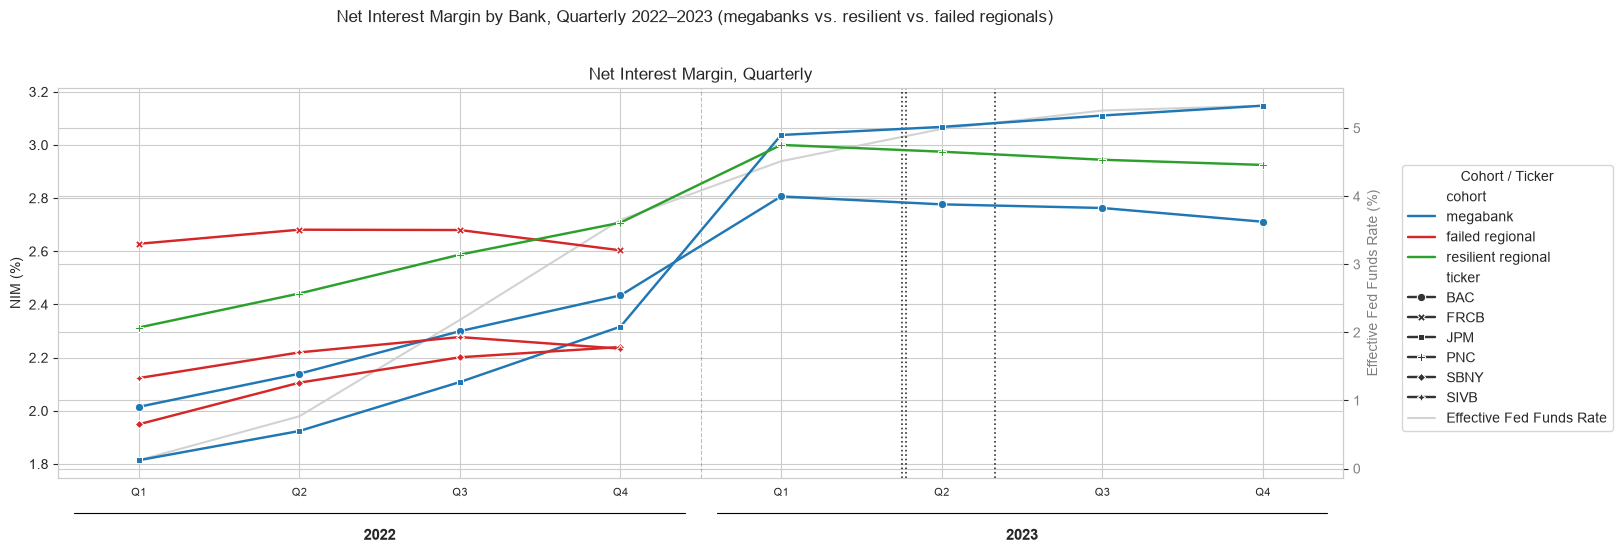

In [60]:
"""NIM TRENDS (QUARTERLY), by bank, colored by cohort, with a multi-level (quarter/year) x-axis"""

period_order = (
    NIM_quarterly[["year", "quarter"]]
    .drop_duplicates()
    .assign(quarter_num=lambda d: d["quarter"].str[1].astype(int))
    .sort_values(["year", "quarter_num"])
    .reset_index(drop=True)
)
period_order["x"] = period_order.index
period_to_x = period_order.set_index(["year", "quarter"])["x"]

NIM_quarterly["x"] = NIM_quarterly.set_index(["year", "quarter"]).index.map(period_to_x)

fed_funds_chart = pd.merge(
    fed_funds_quarterly, period_order[["year", "quarter", "x"]], on=["year", "quarter"], how="inner"
).sort_values("x")

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Secondary right-hand axis for the Fed Funds Rate helper line -- drawn behind
# the main axes (ax raised above ax2, ax's own background hidden) so it reads
# as a subtle backdrop rather than competing with the per-bank series.
ax2 = ax.twinx()
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)

ax2.plot(
    fed_funds_chart["x"], fed_funds_chart["fed_funds_rate"],
    color="grey", alpha=0.35, linewidth=1.5, zorder=0,
    label="Effective Fed Funds Rate",
)
ax2.set_ylabel("Effective Fed Funds Rate (%)", color="grey")
ax2.tick_params(axis="y", labelcolor="grey")

sns.lineplot(
    data=NIM_quarterly,
    x="x",
    y="NIM",
    hue="cohort",
    style="ticker",
    palette=cohort_palette,
    markers=True,
    dashes=False,
    markersize=6,
    linewidth=1.75,
    ax=ax,
)

ax.set_title("Net Interest Margin, Quarterly")
ax.set_xlabel("")
ax.set_ylabel("NIM (%)")

ax.set_xticks(period_order["x"])
ax.set_xticklabels(period_order["quarter"], fontsize=8)
ax.set_xlim(-0.5, period_order["x"].max() + 0.5)

year_groups = period_order.groupby("year")["x"].agg(["min", "max"])
trans = ax.get_xaxis_transform()

for year, row in year_groups.iterrows():
    center = (row["min"] + row["max"]) / 2
    ax.plot(
        [row["min"] - 0.4, row["max"] + 0.4], [-0.09, -0.09],
        transform=trans, color="black", linewidth=0.8, clip_on=False,
    )
    ax.text(center, -0.13, str(year), transform=trans, ha="center", va="top", fontsize=11, fontweight="bold")

for year, row in year_groups.iloc[1:].iterrows():
    ax.axvline(row["min"] - 0.5, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)

failure_dates = {
    "SIVB": pd.Timestamp("2023-03-10"),
    "SBNY": pd.Timestamp("2023-03-12"),
    "FRCB": pd.Timestamp("2023-05-01"),
}

def date_to_x(date):
    period = date.to_period("Q")
    key = (period.year, f"Q{period.quarter}")
    if key not in period_to_x:
        return None
    q_start, q_end = period.start_time, period.end_time
    frac = (date - q_start) / (q_end - q_start)
    return period_to_x[key] + frac

failure_x = {ticker: x for ticker, date in failure_dates.items() if (x := date_to_x(date)) is not None}

for x_pos in failure_x.values():
    ax.axvline(x_pos, color="black", linewidth=1.2, linestyle=":", alpha=0.8, zorder=1)

handles, labels = ax.get_legend_handles_labels()
fedfunds_handles, fedfunds_labels = ax2.get_legend_handles_labels()
ax.legend_.remove()
fig.legend(handles + fedfunds_handles, labels + fedfunds_labels,
           loc="center left", bbox_to_anchor=(1.0, 0.5), title="Cohort / Ticker")

fig.suptitle("Net Interest Margin by Bank, Quarterly 2022–2023 (megabanks vs. resilient vs. failed regionals)")
plt.tight_layout()
plt.subplots_adjust(bottom=0.2, top=0.85)
plt.show()

In [61]:
"""HISTORICAL STOCK PRICE DOWNLOAD"""
# This will show whether the market knew the regionals were struggling before they collapsed.

stock_BAC = yf.download("BAC", period="10y")
stock_FRCB = yf.download("FRCB", period="10y")
stock_JPM = yf.download("JPM", period="10y")
stock_PNC = yf.download("PNC", period="10y")
stock_SIVB = yf.download("SIVB.VI", period="10y")

#Accessing historical SBNY data manually through a csv downloaded from Investing.com, because yfinance only has post-collapse data for the bank.
stock_SBNY = pd.read_csv("data/raw/other_stock_market_data/Signature Bank Stock Price History.csv")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [62]:
"""STOCK PRICE PROCESSING (monthly average close, same 2022-2023 window as the quarterly NIM chart above)"""

def close_series(raw_download, ticker_label):
    s = raw_download["Close"]
    if isinstance(s, pd.DataFrame):
        s = s.iloc[:, 0]
    return s.rename(ticker_label)

def trim_stale_tail(s, min_run=10):
    # SIVB.VI (the only listing yfinance has for SVB post-delisting) keeps returning a frozen
    # last-quote price with zero volume once trading actually stopped. A real price series
    # doesn't hold perfectly flat for 10+ consecutive sessions, so drop any such trailing run.
    vals = s.to_numpy()
    n = len(vals)
    if n == 0:
        return s
    i = n - 1
    run = 1
    while i > 0 and vals[i] == vals[i - 1]:
        run += 1
        i -= 1
    return s.iloc[:i] if run >= min_run else s

raw_downloads = {"BAC": stock_BAC, "FRCB": stock_FRCB, "JPM": stock_JPM, "PNC": stock_PNC, "SIVB": stock_SIVB}
stock_series = {ticker: trim_stale_tail(close_series(raw, ticker)) for ticker, raw in raw_downloads.items()}

# SBNY sourced separately (manual csv); keep its post-collapse OTC trading, it's real (unlike SIVB's frozen quote)
stock_series["SBNY"] = (
    stock_SBNY.assign(Date=pd.to_datetime(stock_SBNY["Date"]))
    .set_index("Date")["Price"]
    .sort_index()
    .rename("SBNY")
)

stock_long = pd.concat(
    [pd.DataFrame({"Date": pd.to_datetime(s.index), "close": s.to_numpy(), "ticker": ticker})
     for ticker, s in stock_series.items()],
    ignore_index=True,
)
stock_long["cohort"] = stock_long["ticker"].map(cohort_map)

# Same window as the quarterly Call Report / NIM charts above (2022-2023)
stock_window = stock_long.loc[(stock_long["Date"] >= "2022-01-01") & (stock_long["Date"] <= "2023-12-31")].copy()

stock_monthly = (
    stock_window.groupby(["ticker", pd.Grouper(key="Date", freq="ME")])["close"]
    .mean()
    .reset_index()
)
stock_monthly["cohort"] = stock_monthly["ticker"].map(cohort_map)
stock_monthly["year"] = stock_monthly["Date"].dt.year
stock_monthly["month"] = stock_monthly["Date"].dt.month


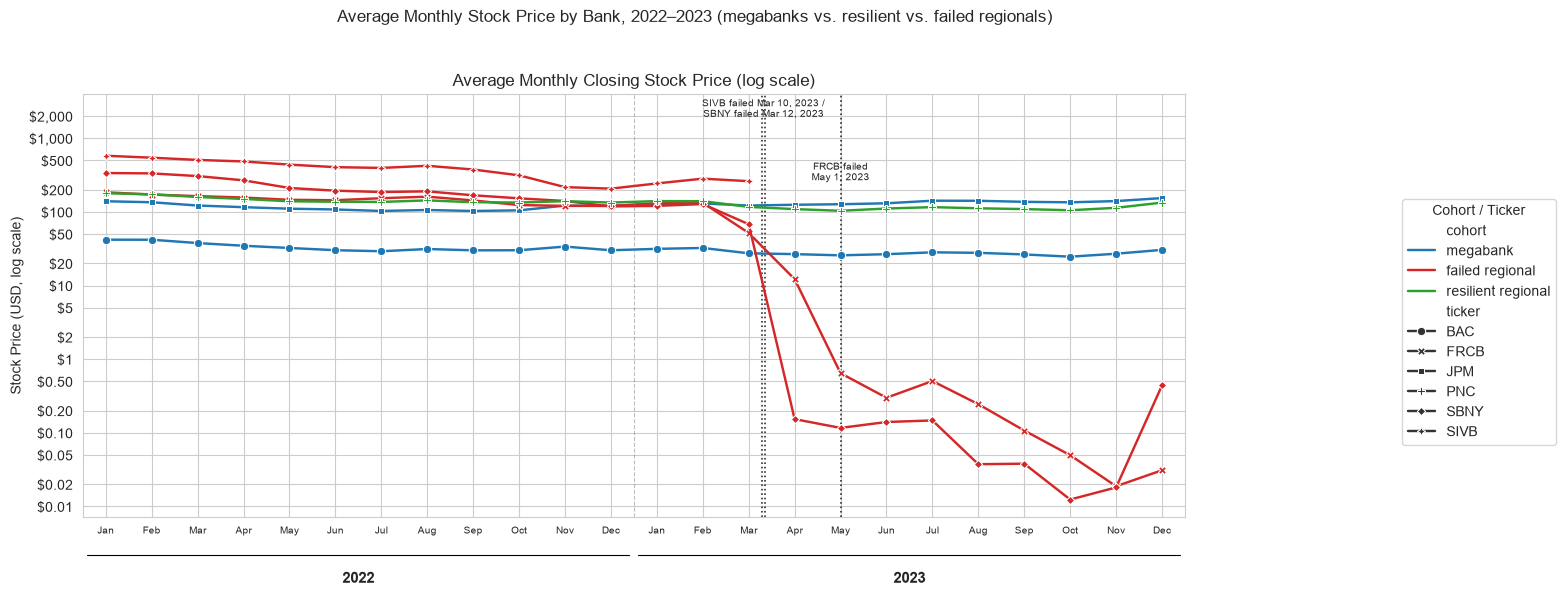

In [63]:
"""AVERAGE MONTHLY STOCK PRICE (2022-2023), by bank, colored by cohort, log-scaled y-axis
(megabanks trade in the tens/hundreds of dollars, failed regionals collapse to cents -- a
linear axis would flatten the failed regionals to an invisible line at the bottom)"""
import calendar
from matplotlib.ticker import FuncFormatter, LogLocator

full_months = pd.period_range("2022-01", "2023-12", freq="M")
period_order = pd.DataFrame({"year": full_months.year, "month": full_months.month})
period_order["x"] = range(len(period_order))
period_order["month_label"] = period_order["month"].map(lambda m: calendar.month_abbr[m])
period_to_x = period_order.set_index(["year", "month"])["x"]

stock_monthly["x"] = stock_monthly.set_index(["year", "month"]).index.map(period_to_x)

fig, ax = plt.subplots(1, 1, figsize=(14, 6.5))

sns.lineplot(
    data=stock_monthly,
    x="x",
    y="close",
    hue="cohort",
    style="ticker",
    palette=cohort_palette,
    markers=True,
    dashes=False,
    markersize=6,
    linewidth=1.75,
    ax=ax,
)

ax.set_yscale("log")
ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"${y:,.0f}" if y >= 1 else f"${y:.2f}"))
ax.yaxis.set_minor_formatter(FuncFormatter(lambda y, _: ""))
ax.set_ylim(top=ax.get_ylim()[1] * 4)  # headroom for the failure-date labels

ax.set_title("Average Monthly Closing Stock Price (log scale)")
ax.set_xlabel("")
ax.set_ylabel("Stock Price (USD, log scale)")

# --- Level 1: month ticks ---
ax.set_xticks(period_order["x"])
ax.set_xticklabels(period_order["month_label"], fontsize=7)
ax.set_xlim(-0.5, period_order["x"].max() + 0.5)

# --- Level 2: year labels centered under each group of months, with a bracket line ---
year_groups = period_order.groupby("year")["x"].agg(["min", "max"])
trans = ax.get_xaxis_transform()

for year, row in year_groups.iterrows():
    center = (row["min"] + row["max"]) / 2
    ax.plot(
        [row["min"] - 0.4, row["max"] + 0.4], [-0.09, -0.09],
        transform=trans, color="black", linewidth=0.8, clip_on=False,
    )
    ax.text(center, -0.13, str(year), transform=trans, ha="center", va="top", fontsize=11, fontweight="bold")

for year, row in year_groups.iloc[1:].iterrows():
    ax.axvline(row["min"] - 0.5, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)

# --- Approximate bank failure dates, as vertical reference lines ---
failure_dates = {
    "SIVB": pd.Timestamp("2023-03-10"),
    "SBNY": pd.Timestamp("2023-03-12"),
    "FRCB": pd.Timestamp("2023-05-01"),
}

def date_to_x(date):
    period = date.to_period("M")
    key = (period.year, period.month)
    if key not in period_to_x:
        return None
    m_start, m_end = period.start_time, period.end_time
    frac = (date - m_start) / (m_end - m_start)
    return period_to_x[key] + frac

failure_x = {ticker: x for ticker, date in failure_dates.items() if (x := date_to_x(date)) is not None}

for x_pos in failure_x.values():
    ax.axvline(x_pos, color="black", linewidth=1.2, linestyle=":", alpha=0.8, zorder=1)

ax.text(
    (failure_x["SIVB"] + failure_x["SBNY"]) / 2, 0.99,
    "SIVB failed Mar 10, 2023 /\nSBNY failed Mar 12, 2023",
    transform=trans, ha="center", va="top", fontsize=7,
)
ax.text(failure_x["FRCB"], 0.84, "FRCB failed\nMay 1, 2023", transform=trans, ha="center", va="top", fontsize=7)

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), title="Cohort / Ticker")

fig.suptitle("Average Monthly Stock Price by Bank, 2022\u20132023 (megabanks vs. resilient vs. failed regionals)")
plt.tight_layout()
plt.subplots_adjust(bottom=0.2, top=0.85, right=0.85)
plt.show()


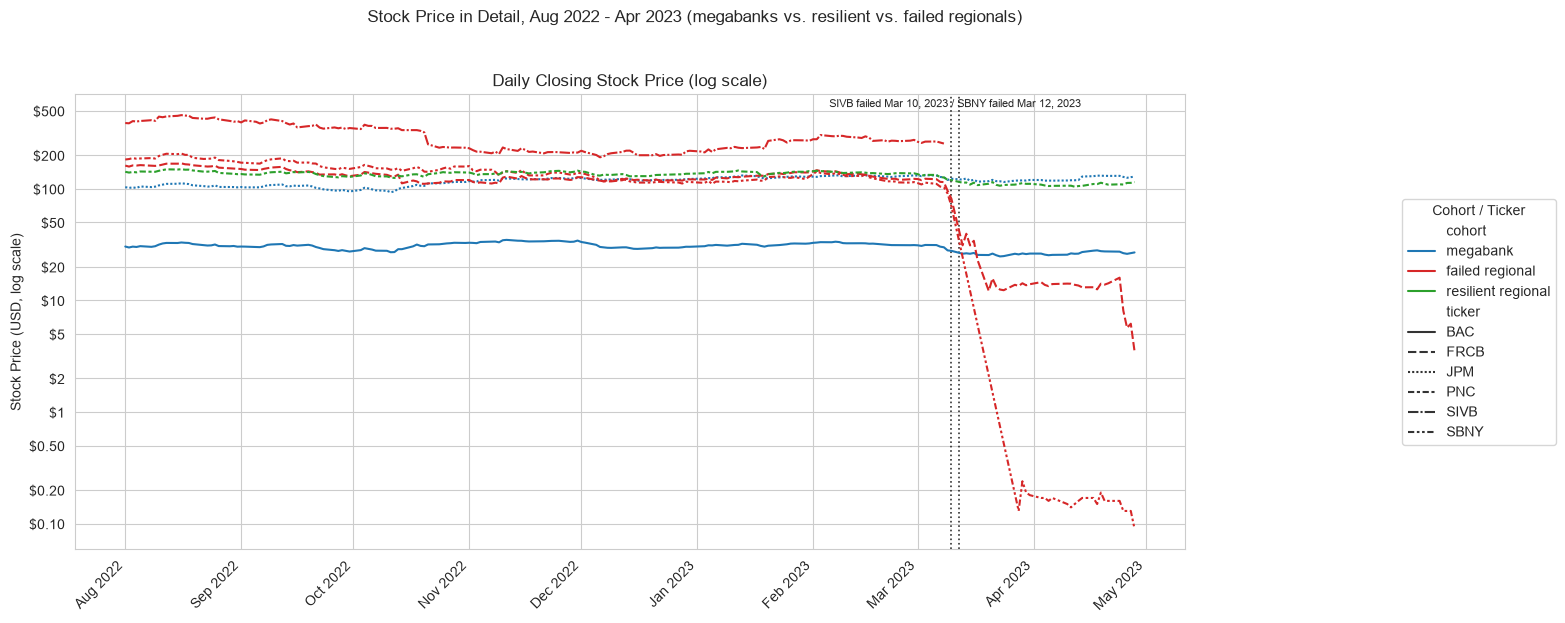

In [64]:
"""DETAILED DAILY STOCK PRICE (Aug 2022 - Apr 2023), by bank, colored by cohort, log-scaled y-axis
Same underlying series as the Average Monthly Stock Price chart above (stock_long), but at daily
granularity and zoomed into the run-up to the March 2023 failures instead of monthly averages."""
import matplotlib.dates as mdates

detail_start, detail_end = "2022-08-01", "2023-04-30"
stock_detail = stock_long.loc[
    (stock_long["Date"] >= detail_start) & (stock_long["Date"] <= detail_end)
].copy()

fig, ax = plt.subplots(1, 1, figsize=(14, 6.5))

sns.lineplot(
    data=stock_detail,
    x="Date",
    y="close",
    hue="cohort",
    style="ticker",
    palette=cohort_palette,
    dashes=True,
    linewidth=1.5,
    ax=ax,
)

ax.set_yscale("log")
ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"${y:,.0f}" if y >= 1 else f"${y:.2f}"))
ax.yaxis.set_minor_formatter(FuncFormatter(lambda y, _: ""))

ax.set_title("Daily Closing Stock Price (log scale)")
ax.set_xlabel("")
ax.set_ylabel("Stock Price (USD, log scale)")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate(rotation=45, ha="right")

# --- Approximate bank failure dates, as vertical reference lines (FRCB failed May 1, 2023, just outside this window) ---
failure_dates_detail = {
    "SIVB": pd.Timestamp("2023-03-10"),
    "SBNY": pd.Timestamp("2023-03-12"),
}

trans = ax.get_xaxis_transform()
for date in failure_dates_detail.values():
    ax.axvline(date, color="black", linewidth=1.2, linestyle=":", alpha=0.8, zorder=1)

ax.text(
    failure_dates_detail["SIVB"] + (failure_dates_detail["SBNY"] - failure_dates_detail["SIVB"]) / 2,
    0.99, "SIVB failed Mar 10, 2023 / SBNY failed Mar 12, 2023",
    transform=trans, ha="center", va="top", fontsize=8,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), title="Cohort / Ticker")

fig.suptitle("Stock Price in Detail, Aug 2022 - Apr 2023 (megabanks vs. resilient vs. failed regionals)")
plt.tight_layout()
plt.subplots_adjust(bottom=0.15, top=0.85, right=0.85)
plt.show()


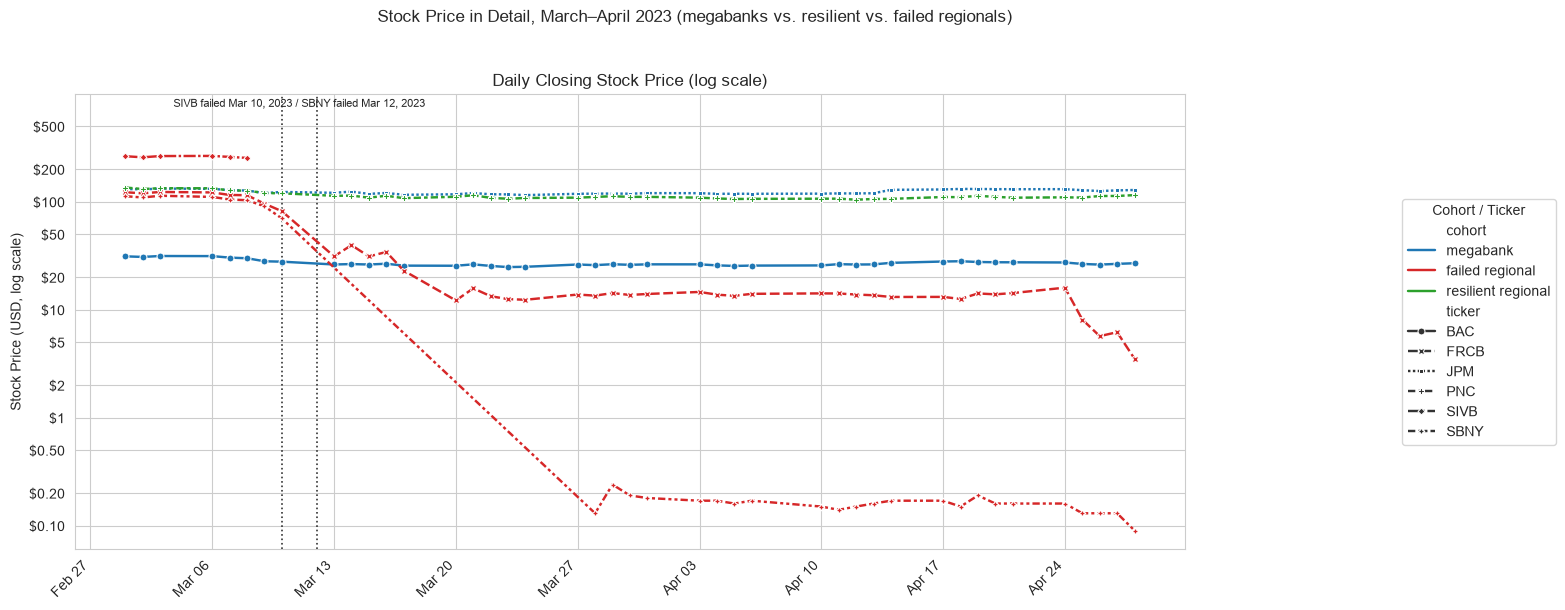

In [65]:
"""DETAILED DAILY STOCK PRICE, ZOOMED TO MARCH-APRIL 2023, by bank, colored by cohort, log-scaled y-axis
Same underlying series as the two stock price charts above (stock_long), but narrowed to the six-week
run on SIVB/SBNY and its immediate aftermath so the day-to-day collapse is legible."""

zoom_start, zoom_end = "2023-03-01", "2023-04-30"
stock_zoom = stock_long.loc[
    (stock_long["Date"] >= zoom_start) & (stock_long["Date"] <= zoom_end)
].copy()

fig, ax = plt.subplots(1, 1, figsize=(14, 6.5))

sns.lineplot(
    data=stock_zoom,
    x="Date",
    y="close",
    hue="cohort",
    style="ticker",
    palette=cohort_palette,
    dashes=True,
    markers=True,
    markersize=5,
    linewidth=1.75,
    ax=ax,
)

ax.set_yscale("log")
ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"${y:,.0f}" if y >= 1 else f"${y:.2f}"))
ax.yaxis.set_minor_formatter(FuncFormatter(lambda y, _: ""))
ax.set_ylim(top=ax.get_ylim()[1] * 2.5)  # headroom for the failure-date label

ax.set_title("Daily Closing Stock Price (log scale)")
ax.set_xlabel("")
ax.set_ylabel("Stock Price (USD, log scale)")

ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_minor_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.autofmt_xdate(rotation=45, ha="right")

# --- Bank failure dates that fall inside this window, as vertical reference lines ---
# (FRCB failed May 1, 2023 -- outside the Mar-Apr window -- so it's excluded here)
failure_dates_zoom = {
    "SIVB": pd.Timestamp("2023-03-10"),
    "SBNY": pd.Timestamp("2023-03-12"),
}

trans = ax.get_xaxis_transform()
for date in failure_dates_zoom.values():
    ax.axvline(date, color="black", linewidth=1.2, linestyle=":", alpha=0.8, zorder=1)

ax.text(
    failure_dates_zoom["SIVB"] + (failure_dates_zoom["SBNY"] - failure_dates_zoom["SIVB"]) / 2,
    0.99, "SIVB failed Mar 10, 2023 / SBNY failed Mar 12, 2023",
    transform=trans, ha="center", va="top", fontsize=8,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend_.remove()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), title="Cohort / Ticker")

fig.suptitle("Stock Price in Detail, March–April 2023 (megabanks vs. resilient vs. failed regionals)")
plt.tight_layout()
plt.subplots_adjust(bottom=0.15, top=0.85, right=0.85)
plt.show()


**STOCK PRICE OBSERVATION**

When we take a detailed look at the Stock Price of the 3 failed regionals, we notice that the market wasn't able to infer the amount of financial strain the regionals where under in the long term. The valuations remained steady (and even grew, as in the case of SIVB) up until the very moment the run on SIVB took place. Despite the soon-to-be-failed regionals' high % of Uninsured Deposits, growing HTM unrealized losses, and moderate Net Interest Margin compression being visible for up to months in advance - the market only reacted with the failure of the first regional - SIVB. Afterwards the reaction was swift, FRCB and SBNY stocks plumetted. But not every regional was suspected of failure - PNC maintained an even valuation as it's regional peers went underwater.

# FINAL SUMMARY:

The central theme of this analysis was to check if the failed regionals (SIVB, FRCB, SBNY) showed any measurable pre-failure stress, as compared to the megabanks (BAC, JPM) and resilient regional (PNC). From the first batch of derived metrics we’ve seen some that didn’t make the failed group stand out - ROA (Return on Assets) and ROE (Return on Equity) failed to pinpoint the distinguishing factor between the failed and resilient banks. NIM (Net Interest Margin) was slightly more useful, showing mild compression for the failed group. A 95% CI Bootstrap confirmed notable differences in NIM between the failed and surviving cohorts - indicating financial stress was enveloping the regionals. A theme corroborated by the ER (Efficiency Ratio), which showed how the soon-to-collapse banks struggled with a mounting wave of expenses – this being visible in the ER trend slope derived with linear regression.

These accumulated costs made themselves apparent with AOCI-normalized (Accumulated other comprehensive income), which showed how almost all regionals - both failed and resilient - had their capital eroded. SIVB has shown the most visible degeneration in its finances through the tremendous losses stemming from purchasing securities at low interest, right before steady rate hikes completely devalued them. This financial hit is visible in the abysmally high HTM-unrealized-loss-normalized for SIVB.

However these metrics give us clues about the struggle of regional banks in 2022 and 2023, the foundation for their fragility has been laid not as an unexpected event, but a long-term lapse in judgement. The failure of the 3 banks is defined by the extremely high % of uninsured deposits they held. Starting in 2022, the withdrawal pressures on all banks increased due to the rate hike, this shrunk the deposits (as seen in deposit growth % falling, often into deposit contraction) and produced higher deposit betas (particularly for SIVB, the first bank to fail), meaning the higher cost of holding deposits was compressing the regional’s already fragile margins.

The best window into this instability being the Uninsured deposits % vs. AOCI-normalized scatterplot. It shows a rift between the soon-to-fail banks, from the entrenched megabanks and the resilient PNC regional which survived, with uninsured deposits % being one of the most important factors to the collapse. A gap-vs-spread calculation confirms that this metric is the distinguishing factor between the banks that failed (High Uninsured deposit %) for those that survived (Low uninsured deposit %).

This analysis was meant to roughly answer the question, whether the 2023 wave of bank runs on American regionals could’ve been foreseen. Thanks to stock price analysis, we can infer that the stakeholders in the failed banks had no idea about the magnitudes of financial strain the regionals were undergoing. Only when the flash run on SIVB happened, did the market grasp the fragility of the regionals’, with stock prices plummeting for all the banks that would go on to fail.

An important caveat: The scope of this project is limited. The low number of banks per cohort (3 - failed regionals / 1 - resilient regional / 2 - megabanks) means there is no basis to call any findings of this analysis predictive of the outcomes for the banks. The fact some of the banks failed before they could file 10-Q / 10-K / FDIC Call Report documents, also results in an absence of FY2023 data.

However patchy, this analysis has put on display how bad policy decisions can go unnoticed for months, and before management knows it - they can sink the bank in a heartbeat. For all the regionals, there has been a clear combination of high uninsured deposit % coming into a collision with a rate hike. However one might try to pin the cause for the collapse on any one of these metrics, there are things outside of the scope of this project (like the social-media-induced panic, and the unprecedented pace at which you can withdraw tens of thousands of dollars without even having to be at the bank in person), that have contributed to the collapse.
